In [1]:
import os
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import datetime
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import to_rgba
import seaborn as sns
sns.set()
from tqdm.notebook import tqdm
import vector
import itertools
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from collections import defaultdict

import tensorflow as tf
import tensorflow.saved_model
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Add, Activation
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Normalization
from tensorflow.keras.callbacks import Callback
from tensorflow.keras import regularizers
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.models import Model, model_from_json, load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from lbn import LBN, LBNLayer

import mplhep as hep
hep.style.use("CMS")

print("ok")

2025-02-27 13:57:12.391227: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-27 13:57:12.392344: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-27 13:57:12.397254: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-27 13:57:12.449701: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-27 13:57:16.411948: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF

ok


In [2]:
import logging
def setup_logger(log_file):
    """
    Sets up a logger that logs messages to both a file and the console.

    Args:
        log_file (str): Path to the log file where logs will be written.

    Returns:
        logging.Logger: Configured logger instance.
    
    The logger:
    - Logs messages at the DEBUG level and above.
    - Outputs logs to both the specified file and the console.
    - Uses a consistent log format including timestamp, log level, filename, and line number.
    """
    # Create a logger                                                                                                                                                             
    logger = logging.getLogger('main')
    logger.setLevel(logging.DEBUG)

    # Create a file handler                                                                                                                                                       
    file_handler = logging.FileHandler(log_file)
    file_handler.setLevel(logging.DEBUG)

    # Create a console handler                                                                                                                                                    
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.DEBUG)

    # Create a formatter and add it to the file handler                                                                                                                           
    formatter = logging.Formatter('%(asctime)s,%(msecs)03d %(levelname)-8s [%(filename)s:%(lineno)d] %(message)s','%Y-%m-%d:%H:%M:%S')
    file_handler.setFormatter(formatter)
    console_handler.setFormatter(formatter)

    # Add the file handler to the logger                                                                                                                                          
    logger.addHandler(file_handler)
    logger.addHandler(console_handler)

    return logger

In [3]:
tf.__version__

# List the available physical devices (CPU, GPU)
devices = tf.config.list_physical_devices()
print("\nDevices: ", devices)

# List the available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    details = tf.config.experimental.get_device_details(gpus[0])
    print("GPU details: ", details)


Devices:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [4]:
tag_ = "DNN_Higgs_Flat_Feb25"
tagdir = os.path.join(os.getcwd(), tag_)
print(tagdir)
if not os.path.exists(tagdir):
    os.mkdir(tagdir)
else:
    print(f"{tag_} exists")

/pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25
DNN_Higgs_Flat_Feb25 exists


In [5]:
# Get the current date and time
dttag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
n_particles = 10 # why 10? what are these 10 aprticles ? with channel? 
lbn_feat_names = ["E", "px", "py", "pz", "pt", "eta", "phi", "p", "m", "pair_cos","pair_dr"]
train = True # If false, load the model and evaluate
nepochs = 300 # Number of epochs
evaluate = True # If true, evaluate the model
#hereismodel = f"{tagdir}/training_20240426-125220/cp.ckpt"
hereismodeldir = os.path.join(os.getcwd(), "DNN_Higgs_Flat_Feb25")

# A checkpoint (.ckpt) is a snapshot of a model's trainable variables (weights and biases).
# It does not store the model's architecture—only the parameters.
hereismodel = f"{hereismodeldir}/training_1/cp.ckpt"

# Create a directory to store the run logs
runlogdir = os.path.join(tagdir, "runlogs")

if not os.path.exists(runlogdir):
    os.mkdir(runlogdir)

logger = setup_logger(os.path.join(runlogdir, f"runlog_{dttag}.log"))

In [6]:
logger.info(f"date-time      : {dttag}")
logger.info(f"nLBNPart       : {n_particles}") # Number of particles in the LBN
logger.info(f"lbn feat names : {str(lbn_feat_names)}") # Features used in the LBN
logger.info(f"do train       : {train}") # Train the model
logger.info(f"nEpochs        : {nepochs}") # Number of epochs
logger.info(f"model loded    : {hereismodel}") # Model to load
logger.info(f"Out dir        : {tagdir}")   # Output directory

2025-02-27:13:57:23,169 INFO     [2562202180.py:1] date-time      : 20250227_135723
2025-02-27:13:57:23,170 INFO     [2562202180.py:2] nLBNPart       : 10
2025-02-27:13:57:23,171 INFO     [2562202180.py:3] lbn feat names : ['E', 'px', 'py', 'pz', 'pt', 'eta', 'phi', 'p', 'm', 'pair_cos', 'pair_dr']
2025-02-27:13:57:23,172 INFO     [2562202180.py:4] do train       : True
2025-02-27:13:57:23,173 INFO     [2562202180.py:5] nEpochs        : 300
2025-02-27:13:57:23,174 INFO     [2562202180.py:6] model loded    : /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25/training_1/cp.ckpt
2025-02-27:13:57:23,174 INFO     [2562202180.py:7] Out dir        : /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25


In [7]:
#df_ = "GluGluHToTauTauSMdata_ForTrain_Raw_11_simple_IC_20240417_183354.h5"
# df_ = "GluGluHToTauTau_ForTrain_Raw_11_simple_MB_20240501_082537.h5"
#df_ = "GluGluHToTauTauFlat_ForTrain_Raw_11_simple_MB_20240501_082908.h5"
#df_ = "Flat_GluGluHToTauTauSMdata_ForTrain_Raw_11_simple_IC_20240418_192329.h5"


#df_ = "GluGluHToTauTauSMdata_ForTrain_Raw_11_simple_IC_20240416_133720.h5"
#df_ = "GluGluHToTauTauSMdata_ForTrain_Raw_11_simple_MB_20240416_145614.h5"
#df_ = "Flat_GluGluHToTauTauSMdata_ForTrain_Raw_11_simple_IC_20240417_064445.h5"

df_ = "GluGluHToTauTauFlat_ForTrain_Raw_11_simple_IC_20240627_163559.h5"




df_tag_ = f"""{df_.split(".")[0]}_nPart_{n_particles}_executed_on_{dttag}"""

In [8]:
logger.info(f"dataframe      : {df_}")

2025-02-27:13:57:23,204 INFO     [776286069.py:1] dataframe      : GluGluHToTauTauFlat_ForTrain_Raw_11_simple_IC_20240627_163559.h5


In [9]:
# Load the TensorBoard notebook extension
#%reload_ext tensorboard
#from tensorboard import notebook
#notebook.list() # View open TensorBoard instances
## Control TensorBoard display. If no port is provided, 
## the most recently launched TensorBoard is used
#notebook.display(port=6006, height=1000)

In [69]:
def PlotHistory(history, path=None, df_tag_=df_tag_):
    """ Takes history from Keras training and makes loss plots (batch and epoch) and learning rate plots """
    #----- Figure -----#
    variables = sorted([key for key in history.history.keys() if 'val' not in key and 'val_'+key in history.history.keys()])
    # variables += ["lr"] # learning rate
    N = len(variables)
    print(f"variables: {variables}")
    fig, ax = plt.subplots(N,2,figsize=(12.5,N*2),sharex='col')
    plt.subplots_adjust(left    = 0.1,
                        right   = 0.6,
                        top     = 0.9,
                        bottom  = 0.1,
                        hspace  = 0.5,
                        wspace  = 0.4)
    
    # #----- Batch Plots -----#
    # for i,var in enumerate(variables):
    #     ax[i,0].plot(history.batches['batch'],history.batches[var],'k')
    #     ax[i,0].set_title(var)
    #     ax[i,0].set_xlabel('Batch')
        
    #----- Epoch Plots -----#
    for i,var in enumerate(variables):
        ax[i,1].plot(history.epoch,history.history[var],label='train')
        print(f"var =  {var}")
        if 'val_'+var in history.history.keys():
            ax[i,1].plot(history.epoch,history.history['val_'+var],label='validation')
        ax[i,1].set_title(var)
        ax[i,1].legend()
        ax[i,1].set_xlabel('Epoch')

    png_name = os.path.join(path,f'Loss_Acc_LR_{df_tag_}.png')
    logger.info(f"Plot saved: {png_name}")
    fig.savefig(png_name, dpi=300)
    print('Curves saved as %s'%png_name)
#######################################################


def getp4(df, vars=[], LVtype=""):
    """
        df: The main dfataframe
        vars = [p4 components of obj]
        LVtype = ptetaphim / pxpypze
    """
    for var in vars:
        if var not in list(df.keys()):
            df[var] = 0.0
    p4 = None
    if LVtype == "ptetaphim":
        p4 = vector.array({"pt": df[vars[0]].to_numpy(),
                           "eta": df[vars[1]].to_numpy(),
                           "phi": df[vars[2]].to_numpy(),
                           "M": df[vars[3]].to_numpy()})
    elif LVtype == "pxpypze":
        p4 = vector.array({"px": df[vars[0]].to_numpy(),
                           "py": df[vars[1]].to_numpy(),
                           "pz": df[vars[2]].to_numpy(),
                           "E": df[vars[3]].to_numpy()})
        

    return p4

def setp4(df, vars=[]):
    p4 = getp4(df, vars=vars)
    obj = vars[0].split('_')[0]
    num = vars[0].split('_')[1]
    key = f'{obj}_{num}' if len(vars[0].split('_')) > 2 else f'{obj}'

    df[f'{key}_px'] = p4.px
    df[f'{key}_py'] = p4.py
    df[f'{key}_pz'] = p4.pz
    df[f'{key}_E']  = p4.E

In [11]:
#indf = "df_DY_v5_processed_scaled_metphi.h5"
#indf = "df_DY_v5_processed.h5"
indf = f"/pbs/home/o/oponcet/private/TauRegression/BasicNN/model/{df_}"

# Load the dataframe from the file in pandas dataframe
df = pd.read_hdf(indf)
#df = df.drop(columns=["total_tau_phi"]) # new

# Drop the rows with NaN values
df = df.dropna()

# Print the first 10 rows of the dataframe
df.head(10)

,npf_tau_1,npf_tau_2,ptfrac_tau_1,ptfrac_tau_2,pf_dphi_pt_frac_tau_1,pf_dphi_pt_frac_tau_2,pf_deta_pt_frac_tau_1,pf_deta_pt_frac_tau_2,pt_tau_1,pt_tau_2,ptCorrPNet_tau_1,ptCorrPNet_tau_2,eta_tau_1,eta_tau_2,phi_tau_1,phi_tau_2,mass_tau_1,mass_tau_2,dxy_tau_1,dxy_tau_2,dz_tau_1,dz_tau_2,rawDeepTau2018v2p5VSe_tau_1,rawDeepTau2018v2p5VSe_tau_2,rawDeepTau2018v2p5VSjet_tau_1,rawDeepTau2018v2p5VSjet_tau_2,rawDeepTau2018v2p5VSmu_tau_1,rawDeepTau2018v2p5VSmu_tau_2,rawIsodR03_tau_1,rawIsodR03_tau_2,rawMVAnewDM2017v2_tau_1,rawMVAnewDM2017v2_tau_2,leadTkPtOverTauPt_tau_1,leadTkPtOverTauPt_tau_2,rawPNetVSe_tau_1,rawPNetVSe_tau_2,rawPNetVSjet_tau_1,rawPNetVSjet_tau_2,rawPNetVSmu_tau_1,rawPNetVSmu_tau_2,charge_tau_1,charge_-1_tau_1,charge_1_tau_1,charge_tau_2,charge_-1_tau_2,charge_1_tau_2,decayModePNet_tau_1,decayModePNet_-1_tau_1,decayModePNet_0_tau_1,decayModePNet_1_tau_1,decayModePNet_2_tau_1,decayModePNet_10_tau_1,decayModePNet_11_tau_1,decayModePNet_tau_2,decayModePNet_-1_tau_2,decayModePNet_0_tau_2,decayModePNet_1_tau_2,decayModePNet_2_tau_2,decayModePNet_10_tau_2,decayModePNet_11_tau_2,probDM0PNet_tau_1,probDM0PNet_tau_2,probDM10PNet_tau_1,probDM10PNet_tau_2,probDM11PNet_tau_1,probDM11PNet_tau_2,probDM1PNet_tau_1,probDM1PNet_tau_2,probDM2PNet_tau_1,probDM2PNet_tau_2,pt_tau1prod_1,pt_tau1prod_2,pt_tau1prod_3,pt_tau1prod_4,pt_tau1prod_5,pt_tau1prod_6,pt_tau1prod_7,pt_tau1prod_8,pt_tau1prod_9,pt_tau1prod_10,eta_tau1prod_1,eta_tau1prod_2,eta_tau1prod_3,eta_tau1prod_4,eta_tau1prod_5,eta_tau1prod_6,eta_tau1prod_7,eta_tau1prod_8,eta_tau1prod_9,eta_tau1prod_10,phi_tau1prod_1,phi_tau1prod_2,phi_tau1prod_3,phi_tau1prod_4,phi_tau1prod_5,phi_tau1prod_6,phi_tau1prod_7,phi_tau1prod_8,phi_tau1prod_9,phi_tau1prod_10,mass_tau1prod_1,mass_tau1prod_2,mass_tau1prod_3,mass_tau1prod_4,mass_tau1prod_5,mass_tau1prod_6,mass_tau1prod_7,mass_tau1prod_8,mass_tau1prod_9,mass_tau1prod_10,pdgId_tau1prod_1,pdgId_tau1prod_2,pdgId_tau1prod_3,pdgId_tau1prod_4,pdgId_tau1prod_5,pdgId_tau1prod_6,pdgId_tau1prod_7,pdgId_tau1prod_8,pdgId_tau1prod_9,pdgId_tau1prod_10,charge_tau1prod_1,charge_tau1prod_2,charge_tau1prod_3,charge_tau1prod_4,charge_tau1prod_5,charge_tau1prod_6,charge_tau1prod_7,charge_tau1prod_8,charge_tau1prod_9,charge_tau1prod_10,pt_tau2prod_1,pt_tau2prod_2,pt_tau2prod_3,pt_tau2prod_4,pt_tau2prod_5,pt_tau2prod_6,pt_tau2prod_7,pt_tau2prod_8,pt_tau2prod_9,pt_tau2prod_10,eta_tau2prod_1,eta_tau2prod_2,eta_tau2prod_3,eta_tau2prod_4,eta_tau2prod_5,eta_tau2prod_6,eta_tau2prod_7,eta_tau2prod_8,eta_tau2prod_9,eta_tau2prod_10,phi_tau2prod_1,phi_tau2prod_2,phi_tau2prod_3,phi_tau2prod_4,phi_tau2prod_5,phi_tau2prod_6,phi_tau2prod_7,phi_tau2prod_8,phi_tau2prod_9,phi_tau2prod_10,mass_tau2prod_1,mass_tau2prod_2,mass_tau2prod_3,mass_tau2prod_4,mass_tau2prod_5,mass_tau2prod_6,mass_tau2prod_7,mass_tau2prod_8,mass_tau2prod_9,mass_tau2prod_10,pdgId_tau2prod_1,pdgId_tau2prod_2,pdgId_tau2prod_3,pdgId_tau2prod_4,pdgId_tau2prod_5,pdgId_tau2prod_6,pdgId_tau2prod_7,pdgId_tau2prod_8,pdgId_tau2prod_9,pdgId_tau2prod_10,charge_tau2prod_1,charge_tau2prod_2,charge_tau2prod_3,charge_tau2prod_4,charge_tau2prod_5,charge_tau2prod_6,charge_tau2prod_7,charge_tau2prod_8,charge_tau2prod_9,charge_tau2prod_10,pt_jet_1,pt_jet_2,pt_jet_3,pt_jet_4,pt_jet_5,pt_jet_6,pt_jet_7,pt_jet_8,pt_jet_9,pt_jet_10,eta_jet_1,eta_jet_2,eta_jet_3,eta_jet_4,eta_jet_5,eta_jet_6,eta_jet_7,eta_jet_8,eta_jet_9,eta_jet_10,phi_jet_1,phi_jet_2,phi_jet_3,phi_jet_4,phi_jet_5,phi_jet_6,phi_jet_7,phi_jet_8,phi_jet_9,phi_jet_10,mass_jet_1,mass_jet_2,mass_jet_3,mass_jet_4,mass_jet_5,mass_jet_6,mass_jet_7,mass_jet_8,mass_jet_9,mass_jet_10,btagPNetB_jet_1,btagPNetB_jet_2,btagPNetB_jet_3,btagPNetB_jet_4,btagPNetB_jet_5,btagPNetB_jet_6,btagPNetB_jet_7,btagPNetB_jet_8,btagPNetB_jet_9,btagPNetB_jet_10,btagDeepFlavB_jet_1,btagDeepFlavB_jet_2,btagDeepFlavB_jet_3,btagDeepFlavB_jet_4,btagDeepFlavB_jet_5,btagDeepFlavB_jet_6,btagDeepFlavB_jet_7,btagDeepFlavB_jet_8,btagDeepFlavB_jet_9,btagDeepFlavB_jet_10,pt_MET,phi_MET,covXX_MET,covXY_MET,covYY_

In [12]:
df["ptlog_gentau_1"] = np.log(df["pt_gentau_1"])
df["ptlog_gentau_2"] = np.log(df["pt_gentau_2"])

In [13]:
#hasnan = list(df.isnull().any())
#for i, col in enumerate(df.keys()):
#    print(f"{col}:\t\t {hasnan[i]}")

In [14]:
#import awkward as ak
#arr = ak.Array((df["rawPNetVSe_tau_1"]).to_numpy())
#ak.to_list(ak.sort(arr))

In [15]:
logger.info(f"df keys         :\n{list(df.keys())}")

2025-02-27:13:57:27,424 INFO     [1491129398.py:1] df keys         :
['npf_tau_1', 'npf_tau_2', 'ptfrac_tau_1', 'ptfrac_tau_2', 'pf_dphi_pt_frac_tau_1', 'pf_dphi_pt_frac_tau_2', 'pf_deta_pt_frac_tau_1', 'pf_deta_pt_frac_tau_2', 'pt_tau_1', 'pt_tau_2', 'ptCorrPNet_tau_1', 'ptCorrPNet_tau_2', 'eta_tau_1', 'eta_tau_2', 'phi_tau_1', 'phi_tau_2', 'mass_tau_1', 'mass_tau_2', 'dxy_tau_1', 'dxy_tau_2', 'dz_tau_1', 'dz_tau_2', 'rawDeepTau2018v2p5VSe_tau_1', 'rawDeepTau2018v2p5VSe_tau_2', 'rawDeepTau2018v2p5VSjet_tau_1', 'rawDeepTau2018v2p5VSjet_tau_2', 'rawDeepTau2018v2p5VSmu_tau_1', 'rawDeepTau2018v2p5VSmu_tau_2', 'rawIsodR03_tau_1', 'rawIsodR03_tau_2', 'rawMVAnewDM2017v2_tau_1', 'rawMVAnewDM2017v2_tau_2', 'leadTkPtOverTauPt_tau_1', 'leadTkPtOverTauPt_tau_2', 'rawPNetVSe_tau_1', 'rawPNetVSe_tau_2', 'rawPNetVSjet_tau_1', 'rawPNetVSjet_tau_2', 'rawPNetVSmu_tau_1', 'rawPNetVSmu_tau_2', 'charge_tau_1', 'charge_-1_tau_1', 'charge_1_tau_1', 'charge_tau_2', 'charge_-1_tau_2', 'charge_1_tau_2', 'decay

In [16]:
num_keys   = ['pt_tau_1', 'pt_tau_2','eta_tau_1', 'eta_tau_2', 'phi_tau_1', 'phi_tau_2',
              'mass_tau_1', 'mass_tau_2', #'dxy_tau_1', 'dxy_tau_2', 'dz_tau_1', 'dz_tau_2',
              #'rawIsodR03_tau_1', 'rawIsodR03_tau_2', # new 
              #'leadTkPtOverTauPt_tau_1',  # new
              #'leadTkPtOverTauPt_tau_2',  # new
              #'rawPNetVSe_tau_1', 'rawPNetVSe_tau_2', # new
              #'rawPNetVSjet_tau_1', 'rawPNetVSjet_tau_2', # new
              #'rawPNetVSmu_tau_1', 'rawPNetVSmu_tau_2', # new
              #'probDM0PNet_tau_1', 'probDM0PNet_tau_2',
              #'probDM1PNet_tau_1', 'probDM1PNet_tau_2', # new
              #'probDM2PNet_tau_1', 'probDM2PNet_tau_2',
              #'probDM10PNet_tau_1', 'probDM10PNet_tau_2',
              #'probDM11PNet_tau_1', 'probDM11PNet_tau_2',
              'pt_jet_1', 'pt_jet_2', 'pt_jet_3', 'pt_jet_4',
              'eta_jet_1', 'eta_jet_2', 'eta_jet_3', 'eta_jet_4',
              'phi_jet_1', 'phi_jet_2', 'phi_jet_3', 'phi_jet_4',
              'mass_jet_1', 'mass_jet_2', 'mass_jet_3', 'mass_jet_4',
              #'btagPNetB_jet_1', 'btagPNetB_jet_2', 'btagPNetB_jet_3', 'btagPNetB_jet_4',
              'npf_tau_1', 'npf_tau_2',   ## NEW !!
              'ptfrac_tau_1', 'ptfrac_tau_2',  ## NEW !!
              #'pf_dphi_pt_frac_tau_1', 'pf_dphi_pt_frac_tau_2', 
              #'pf_deta_pt_frac_tau_1', 'pf_deta_pt_frac_tau_2', 
              'pt_MET', 'phi_MET', 
              'covXX_MET', 'covXY_MET', 'covYY_MET', 'sumEt_MET',  # new
              'significance_MET',  # new
              #'nJet', 
              #'nPV', 
              #'HT', #'MT_total'
             ]
cat_keys = ['charge_-1_tau_1','charge_1_tau_1',
            'charge_-1_tau_2','charge_1_tau_2',
            #'decayModePNet_0_tau_1', 'decayModePNet_1_tau_1', 'decayModePNet_2_tau_1', ## NEW !!
            #'decayModePNet_10_tau_1', 'decayModePNet_11_tau_1', ## NEW !!
            #'decayModePNet_0_tau_2', 'decayModePNet_1_tau_2', 'decayModePNet_2_tau_2', ## NEW !!
            #'decayModePNet_10_tau_2', 'decayModePNet_11_tau_2' ## NEW !!
           ]
target_keys = ['ptlog_gentau_1', 'eta_gentau_1', 'phi_gentau_1', 
               'ptlog_gentau_2', 'eta_gentau_2', 'phi_gentau_2']
#               'k1x', 'k1y', 'k1z',
#               'k2x', 'k2y', 'k2z']
#target_keys = ['h1x', 'h1y', 'h1z',
#               'h2x', 'h2y', 'h2z']

extra_keys = ["pt_tau1pi_1","eta_tau1pi_1","phi_tau1pi_1","mass_tau1pi_1",
              "pt_tau2pi_1","eta_tau2pi_1","phi_tau2pi_1","mass_tau2pi_1",
              "pt_tau1pi0_1","eta_tau1pi0_1","phi_tau1pi0_1","mass_tau1pi0_1",
              "pt_tau2pi0_1","eta_tau2pi0_1","phi_tau2pi0_1","mass_tau2pi0_1",
              "phicp", "phi_cp_det",
              'pt_gentau_1', #'eta_gentau_1', 'phi_gentau_1', 
              'pt_gentau_2', #'eta_gentau_2', 'phi_gentau_2',
              'h1x', 'h1y', 'h1z', 'h2x', 'h2y', 'h2z',
              'k1x', 'k1y', 'k1z', 'k2x', 'k2y', 'k2z',
             ]
keysTokeep = num_keys + cat_keys + target_keys + extra_keys

In [17]:
logger.info(f"main features        : {str(num_keys+cat_keys)}")
logger.info(f"targets              : {str(target_keys)}")
logger.info(f"extra                : {str(extra_keys)}")

2025-02-27:13:57:27,460 INFO     [2678812420.py:1] main features        : ['pt_tau_1', 'pt_tau_2', 'eta_tau_1', 'eta_tau_2', 'phi_tau_1', 'phi_tau_2', 'mass_tau_1', 'mass_tau_2', 'pt_jet_1', 'pt_jet_2', 'pt_jet_3', 'pt_jet_4', 'eta_jet_1', 'eta_jet_2', 'eta_jet_3', 'eta_jet_4', 'phi_jet_1', 'phi_jet_2', 'phi_jet_3', 'phi_jet_4', 'mass_jet_1', 'mass_jet_2', 'mass_jet_3', 'mass_jet_4', 'npf_tau_1', 'npf_tau_2', 'ptfrac_tau_1', 'ptfrac_tau_2', 'pt_MET', 'phi_MET', 'covXX_MET', 'covXY_MET', 'covYY_MET', 'sumEt_MET', 'significance_MET', 'charge_-1_tau_1', 'charge_1_tau_1', 'charge_-1_tau_2', 'charge_1_tau_2']
2025-02-27:13:57:27,461 INFO     [2678812420.py:2] targets              : ['ptlog_gentau_1', 'eta_gentau_1', 'phi_gentau_1', 'ptlog_gentau_2', 'eta_gentau_2', 'phi_gentau_2']
2025-02-27:13:57:27,462 INFO     [2678812420.py:3] extra                : ['pt_tau1pi_1', 'eta_tau1pi_1', 'phi_tau1pi_1', 'mass_tau1pi_1', 'pt_tau2pi_1', 'eta_tau2pi_1', 'phi_tau2pi_1', 'mass_tau2pi_1', 'pt_tau1pi

In [18]:
df = df[keysTokeep]

In [19]:
tau1p4 = getp4(df, vars=["pt_tau_1", "eta_tau_1", "phi_tau_1", "mass_tau_1"], LVtype="ptetaphim")
tau2p4 = getp4(df, vars=["pt_tau_2", "eta_tau_2", "phi_tau_2", "mass_tau_2"], LVtype="ptetaphim")

tausp4 = tau1p4 + tau2p4
print(tausp4.mass)
#plt.hist(tausp4.mass, bins=100, range=[30,130])
#plt.show()
#df["H_vism"] = tausp4.mass
#target_keys = target_keys + ["H_vism"]

[101.43848779  73.965667   100.83001684 ...  98.7749031   72.96057439
 100.70184384]


In [20]:
#df_train, df_test = train_test_split(df,  test_size=0.2,  random_state=42, shuffle=True)
df_train, df_test = train_test_split(df,  test_size=0.2,  shuffle=False) # # Split data: 80% training, 20% testing

In [21]:
# Split features (X) and target values (Y) from the training dataset
df_train_x = df_train.drop(columns=target_keys+extra_keys)  # Drop target & extra columns, keeping only features
df_train_y = df_train[target_keys]  # Keep only the target columns (labels)

# Split features (X) and target values (Y) from the test dataset
df_test_x = df_test.drop(columns=target_keys+extra_keys)  # Drop target & extra columns, keeping only features
df_test_y = df_test[target_keys]  # Keep only the target columns (labels)

# The following lines are commented out but would handle a specific column ("met_phi_raw")
# If uncommented, they would separate "met_phi_raw" as its own dataset and remove it from feature columns.

# Extract the "met_phi_raw" column separately from the training and test features
# df2_met_raw_phi_train = df_train_x[["met_phi_raw"]]
# df2_met_raw_phi_test  = df_test_x[["met_phi_raw"]]

# Remove "met_phi_raw" from the feature set (if needed)
# df_train_x = df_train_x.drop(columns=["met_phi_raw"])
# df_test_x = df_test_x.drop(columns=["met_phi_raw"])

# Get a list of feature column names (after dropping target & extra keys)
feats = list(df_train_x.keys())  # Store feature names as a list for later use


In [22]:
if evaluate:
    df = pd.concat([df_train, df_test], axis=0)

In [23]:
df_train_x

,pt_tau_1,pt_tau_2,eta_tau_1,eta_tau_2,phi_tau_1,phi_tau_2,mass_tau_1,mass_tau_2,pt_jet_1,pt_jet_2,pt_jet_3,pt_jet_4,eta_jet_1,eta_jet_2,eta_jet_3,eta_jet_4,phi_jet_1,phi_jet_2,phi_jet_3,phi_jet_4,mass_jet_1,mass_jet_2,mass_jet_3,mass_jet_4,npf_tau_1,npf_tau_2,ptfrac_tau_1,ptfrac_tau_2,pt_MET,phi_MET,covXX_MET,covXY_MET,covYY_MET,sumEt_MET,significance_MET,charge_-1_tau_1,charge_1_tau_1,charge_-1_tau_2,charge_1_tau_2
0,56.754528,35.064426,-1.060791,-0.026447,0.574463,-2.564941,0.805176,0.878906,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,3.0,2.0,1.000781,1.000279,53.132923,-2.277344,330.0,67.750000,284.0,674.0,7.722656,0.0,1.0,1.0,0.0
1,40.929752,33.084209,1.342041,1.067871,2.825684,-0.123566,0.604004,0.719238,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,4.0,3.0,1.000547,1.000466,29.456814,1.061279,542.0,4.062500,692.0,1452.0,1.329102,0.0,1.0,1.0,0.0
2,49.838066,49.697845,1.944824,1.622803,1.869385,-1.301514,0.939941,0.595703,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,3.0,3.0,1.000330,1.000028,7.774197,1.613525,438.0,-63.750000,638.0,1229.0,0.095032,1.0,0.0,0.0,1.0
3,73.246361,57.675949,0.077606,-0.230988,1.656006,-2.790527,0.717773,0.729492,84.93750,0.0,0.0,0.0,-1.020508,0.0,0.0,0.0,-0.659668,0.0,0.0,0.0,14.359375,0.0,0.0,0.0,2.0,2.0,1.000263,0.999929,3.607110,-2.895508,1396.0,-61.750000,1516.0,2354.0,0.009483,0.0,1.0,1.0,0.0
4,56.222298,53.215492,0.178619,0.600220,-2.957031,0.233917,0.609375,0.932129,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2.0,2.0,1.000284,1.000208,23.089388,2.425293,588.0,4.218750,493.0,1350.0,0.989258,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,57.947773,26.635088,1.035400,1.506836,2.704102,-0.289124,0.715332,0.139526,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2.0,3.0,0.999823,1.001014,9.492948,-0.212677,456.0,-7.812500,422.0,1128.0,0.196777,0.0,1.0,1.0,0.0
796,83.802971,31.966036,0.648193,0.948608,1.129883,-1.562500,0.671875,0.580566,50.53125,0.0,0.0,0.0,-1.644775,0.0,0.0,0.0,-2.947754,0.0,0.0,0.0,6.476562,0.0,0.0,0.0,3.0,2.0,0.999927,1.000085,10.245476,0.126892,348.0,17.375000,263.0,856.5,0.299072,0.0,1.0,1.0,0.0
797,42.159103,36.083836,0.183197,-1.074951,0.833130,-2.492188,0.139526,0.548340,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2.0,3.0,0.999770,1.000600,24.282984,1.146240,479.0,61.125000,530.0,1237.0,1.041016,1.0,0.0,0.0,1.0
798,51.153904,46.255867,0.138336,0.014578,0.552856,-2.604980,0.774414,0.707520,0.00000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,2.0,3.0,1.000046,1.000380,24.262417,-2.341797,634.0,91.000000,540.0,1384.0,0.876465,1.0,0.0,0.0,1.0


In [24]:
df_train_y

,ptlog_gentau_1,eta_gentau_1,phi_gentau_1,ptlog_gentau_2,eta_gentau_2,phi_gentau_2
0,1.362773,-0.044189,-2.562500,1.414630,-1.058594,0.580078
1,1.434418,1.070312,-0.103516,1.402351,1.347656,2.820312
2,1.431712,1.953125,1.859375,1.400761,1.632812,-1.300781
3,1.457190,-0.224609,-2.781250,1.479638,0.084717,1.656250
4,1.443172,0.167480,-2.968750,1.384116,0.599609,0.233398
...,...,...,...,...,...,...
795,1.359531,1.511719,-0.304688,1.462674,1.019531,2.703125
796,1.362773,0.933594,-1.550781,1.480342,0.646484,1.136719
797,1.390942,0.175293,0.839844,1.358220,-1.074219,-2.492188
798,1.446565,0.151367,0.552734,1.389820,0.002319,-2.601562


In [25]:
df_train_x.keys()

Index(['pt_tau_1', 'pt_tau_2', 'eta_tau_1', 'eta_tau_2', 'phi_tau_1',
       'phi_tau_2', 'mass_tau_1', 'mass_tau_2', 'pt_jet_1', 'pt_jet_2',
       'pt_jet_3', 'pt_jet_4', 'eta_jet_1', 'eta_jet_2', 'eta_jet_3',
       'eta_jet_4', 'phi_jet_1', 'phi_jet_2', 'phi_jet_3', 'phi_jet_4',
       'mass_jet_1', 'mass_jet_2', 'mass_jet_3', 'mass_jet_4', 'npf_tau_1',
       'npf_tau_2', 'ptfrac_tau_1', 'ptfrac_tau_2', 'pt_MET', 'phi_MET',
       'covXX_MET', 'covXY_MET', 'covYY_MET', 'sumEt_MET', 'significance_MET',
       'charge_-1_tau_1', 'charge_1_tau_1', 'charge_-1_tau_2',
       'charge_1_tau_2'],
      dtype='object')

## Data engineering for LBN 

In [26]:
def dataset_LBN():    
    import vector
    df_train_x_copy = df_train_x.copy()
    df_test_x_copy = df_test_x.copy()

    def getp4(df, vars=[]):
        #for var in vars:
        #    if var not in list(df.keys()):
        #        df[var] = 0.0
        p4 = vector.array({"pt": df[vars[0]].to_numpy(),
                           "eta": df[vars[1]].to_numpy() if vars[1] in list(df.keys()) else np.zeros_like(df[vars[0]].to_numpy()),
                           "phi": df[vars[2]].to_numpy() if vars[2] in list(df.keys()) else np.zeros_like(df[vars[0]].to_numpy()),
                           "M": df[vars[3]].to_numpy() if vars[3] in list(df.keys()) else np.zeros_like(df[vars[0]].to_numpy())})

        return p4

    def setp4(df, vars=[]):
        p4 = getp4(df, vars=vars)
        obj = vars[0].split('_')[1]
        num = vars[0].split('_')[-1]
        key = f'{obj}_{num}' if len(vars[0].split('_')) > 2 else f'{obj}'

        df[f'px_{key}'] = p4.px
        df[f'py_{key}'] = p4.py
        df[f'pz_{key}'] = p4.pz
        df[f'E_{key}']  = p4.E



    Basics = [['pt_tau_1','eta_tau_1','phi_tau_1','mass_tau_1'],
              ['pt_tau_2','eta_tau_2','phi_tau_2','mass_tau_2'],
              ['pt_jet_1','eta_jet_1','phi_jet_1','mass_jet_1'],
              ['pt_jet_2','eta_jet_2','phi_jet_2','mass_jet_2'],
              ['pt_jet_3','eta_jet_3','phi_jet_3','mass_jet_3'],
              ['pt_jet_4','eta_jet_4','phi_jet_4','mass_jet_4'],
              ['pt_MET','eta_MET','phi_MET','mass_MET']]

    for varlist in Basics:
        setp4(df_train_x_copy, vars=varlist)
        setp4(df_test_x_copy, vars=varlist)


    DNNsToDrop = np.array(Basics).reshape(-1)    
    #print(DNNsToDrop)

    LBNsToKeep = np.char.replace(DNNsToDrop, "pt", "px")
    LBNsToKeep = np.char.replace(LBNsToKeep, "eta", "py")
    LBNsToKeep = np.char.replace(LBNsToKeep, "phi", "pz")
    LBNsToKeep = np.char.replace(LBNsToKeep, "mass", "E")
    LBNsToKeep = list(LBNsToKeep)
    #print(LBNsToKeep)

    #df_train_x_DNN = df_train_x_copy.drop(columns=list(DNNsToDrop)+LBNsToKeep)
    #df_test_x_DNN = df_test_x_copy.drop(columns=list(DNNsToDrop)+LBNsToKeep)
    df_train_x_DNN = df_train_x_copy.drop(columns=LBNsToKeep)
    df_test_x_DNN = df_test_x_copy.drop(columns=LBNsToKeep)

    df_train_x_LBN = df_train_x_copy[LBNsToKeep]
    df_test_x_LBN  = df_test_x_copy[LBNsToKeep]


    ##df_train_x_DNN
    ##df_train_x_DNN
    ##df_train_x_LBN
    ##df_test_x_LBN
    
    #cols_cat = [x for x in list(df_train_x_DNN.keys()) if x.split('_')[0] == 'cat']
    #cols_num = [x for x in list(df_train_x_DNN.keys()) if x.split('_')[0] != 'cat']
    
    x_train_DNN_numerical = df_train_x_DNN[num_keys].to_numpy()
    x_train_DNN_categorical = df_train_x_DNN[cat_keys].to_numpy()
    x_test_DNN_numerical = df_test_x_DNN[num_keys].to_numpy()
    x_test_DNN_categorical = df_test_x_DNN[cat_keys].to_numpy()

    #x_train_DNN = df_train_x_DNN.to_numpy()
    #x_test_DNN = df_test_x_DNN.to_numpy()

    ### ----- Scaling ----- ###
    # Create an instance of StandardScaler, which standardizes features by removing the mean and scaling to unit variance.
    scaler1 = preprocessing.StandardScaler()
    # Fit the scaler to the training data and transform it, i.e., standardize the training features (x_train_DNN_numerical).
    # This calculates the mean and standard deviation from the training data, then applies the scaling.
    x_train_DNN_numerical = scaler1.fit_transform(x_train_DNN_numerical)

    # Apply the same transformation (using the same mean and standard deviation) to the test data (x_test_DNN_numerical).
    # This ensures that the test data is scaled based on the statistics of the training data, maintaining consistency.
    x_test_DNN_numerical  = scaler1.transform(x_test_DNN_numerical)

    x_train_DNN = np.concatenate([x_train_DNN_numerical, x_train_DNN_categorical], axis=1)
    x_test_DNN  = np.concatenate([x_test_DNN_numerical, x_test_DNN_categorical], axis=1)
    ### ------------------- ###
    
    #x_train_DNN = df_train_x_DNN.to_numpy()
    #x_test_DNN  = df_test_x_DNN.to_numpy()
    
    x_train_LBN_ = df_train_x_LBN.to_numpy()
    x_test_LBN_ = df_test_x_LBN.to_numpy()

    ### ----- Scaling ----- ###
    #scaler2 = preprocessing.StandardScaler()
    #x_train_LBN_ = scaler2.fit_transform(x_train_LBN_)
    #x_test_LBN_  = scaler2.transform(x_test_LBN_)
    ### ------------------- ###
    
    x_train_LBN = x_train_LBN_.reshape(-1, x_train_LBN_.shape[-1]//4, 4)
    x_test_LBN = x_test_LBN_.reshape(-1, x_test_LBN_.shape[-1]//4, 4)

    print(x_train_LBN.shape, x_train_DNN.shape)
    print(x_train_LBN.shape, x_test_DNN.shape)
    
    """
    plt.figure(figsize=(20,20))
    for idx, key in enumerate(list(df_train_x_LBN.keys())):
        idx=idx+1
        ax = plt.subplot(7,4,idx)
        arr = x_train_LBN_[:,(idx-1):idx].reshape(-1)
        #print(arr)
        ax.hist(arr, 50, range=[np.min(arr), np.max(arr)], log=True)
        ax.set_title(f"{key}")
    plt.tight_layout()
    """

    feats_DNN = list(df_train_x_DNN.keys())
    
    dict = {'x_train': np.concatenate([x_train_DNN, x_train_LBN_], axis=1),
            'x_test': np.concatenate([x_test_DNN, x_test_LBN_], axis=1),
            'x_train_LBN_keys': list(df_train_x_LBN.keys()),
            'x_train_DNN_keys': list(df_train_x_DNN.keys()),
            'x_train_LBN': x_train_LBN,
            'x_test_LBN': x_test_LBN,
            'x_train_DNN': x_train_DNN,
            'x_test_DNN': x_test_DNN}
    return dict


In [27]:
LBN_dict = dataset_LBN()

feats_name_LBN = LBN_dict['x_train_LBN_keys']
feats_name_DNN = LBN_dict['x_train_DNN_keys']

x_train_LBN =  LBN_dict['x_train_LBN']
x_train_DNN =  LBN_dict['x_train_DNN']
x_test_LBN  =  LBN_dict['x_test_LBN']
x_test_DNN  =  LBN_dict['x_test_DNN']

(173507, 7, 4) (173507, 39)
(173507, 7, 4) (43377, 39)


In [28]:
len(feats_name_DNN), len(feats_name_LBN)

(39, 28)

In [29]:
feats = feats_name_LBN+feats_name_DNN if "LBN" in tag_ else feats
#feats = feats_name_DNN if tag_=="LBN" else feats
len(feats)

39

In [30]:
x_train = df_train_x.to_numpy()
y_train = df_train_y.to_numpy()

x_test = df_test_x.to_numpy()
y_test = df_test_y.to_numpy()

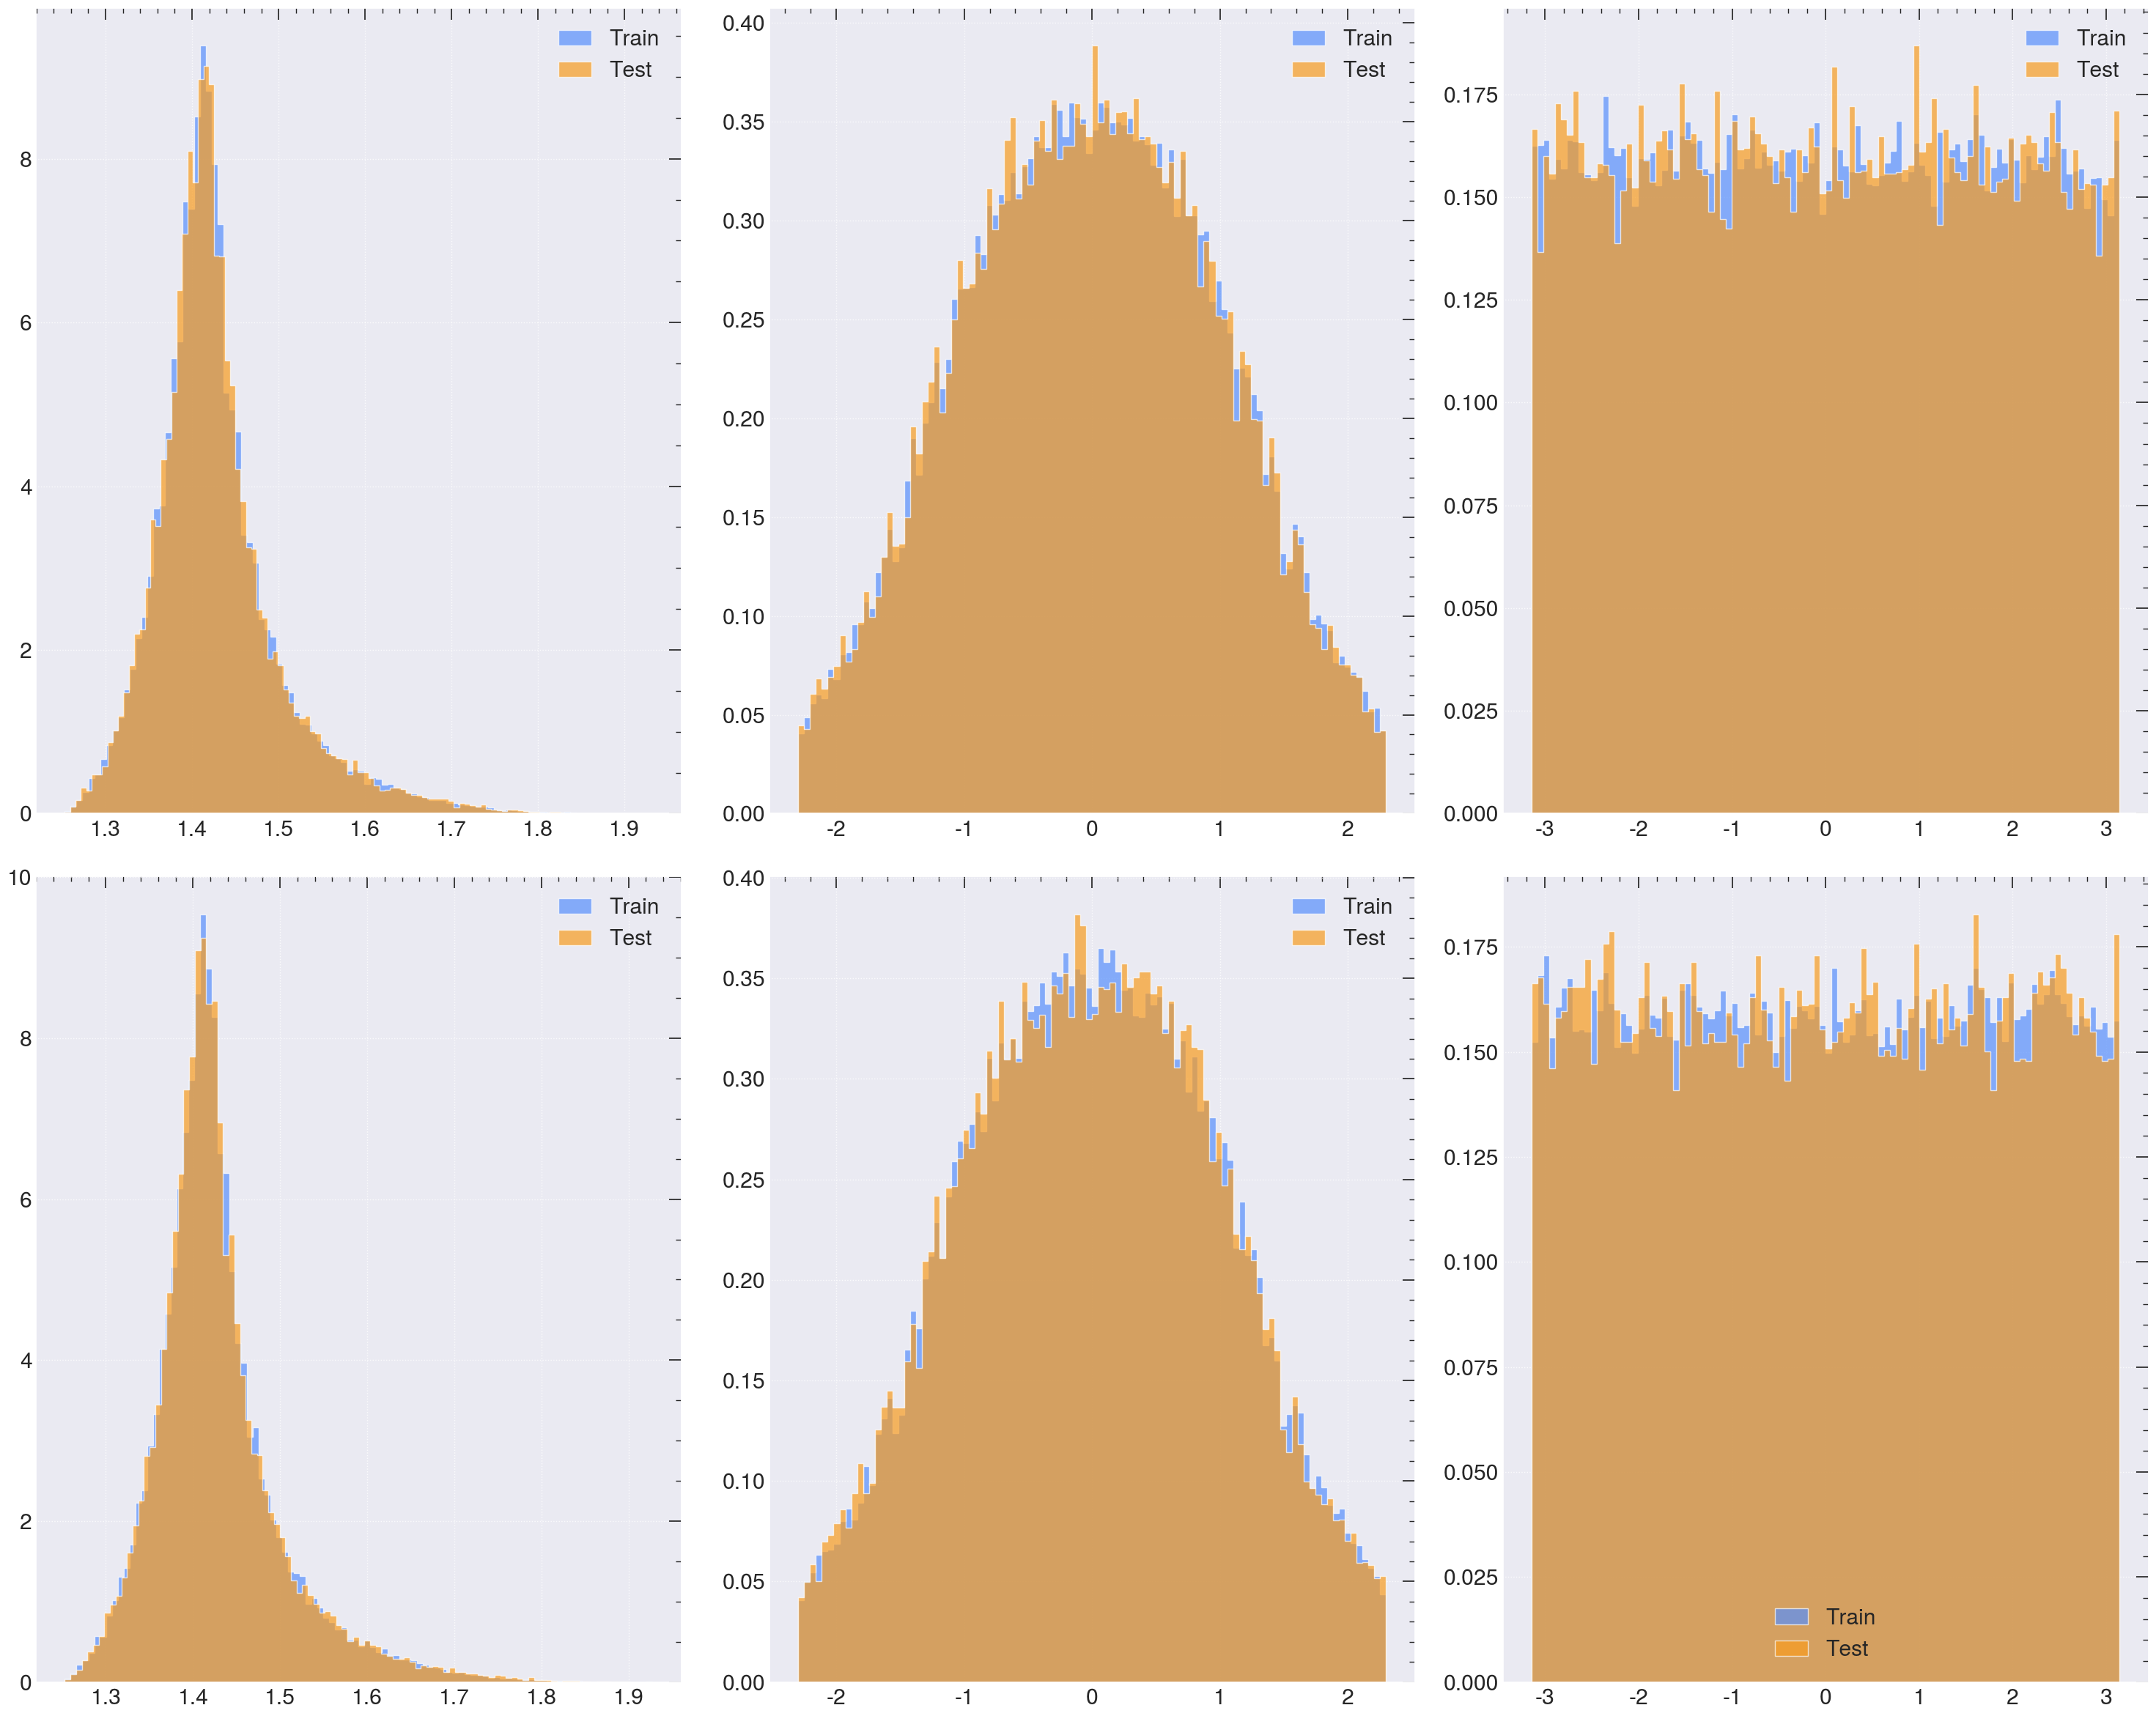

In [31]:
plt.figure(figsize=(30,24))
for idx in range(y_train.shape[-1]):
    idx=idx+1
    ax = plt.subplot(2,3,idx)
    arr_train = y_train[:,idx-1:idx].reshape(-1)
    arr_test  = y_test [:,idx-1:idx].reshape(-1)

    #print(arr)
    minmax = [-50,50] if idx < 7 else [-1,1]
    ax.hist(arr_train, 100, histtype="stepfilled", alpha=0.7, label='Train', log=False, density=True)
    ax.hist(arr_test,  100, histtype="stepfilled", alpha=0.7, label='Test',  log=False, density=True)
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(tagdir,f'target_{df_tag_}.png'), dpi=300)
plt.show()

### Normalise targets

In [32]:
scaler_y = None
"""
scaler_y = preprocessing.StandardScaler()
scale_data = scaler_y.fit(y_train)

y_train = scaler_y.transform(y_train)
y_test  = scaler_y.transform(y_test)
#y_eval  = scaler_y.transform(y_eval)
"""

'\nscaler_y = preprocessing.StandardScaler()\nscale_data = scaler_y.fit(y_train)\n\ny_train = scaler_y.transform(y_train)\ny_test  = scaler_y.transform(y_test)\n#y_eval  = scaler_y.transform(y_eval)\n'

In [33]:
"""
plt.figure(figsize=(30,24))
for idx in range(y_train.shape[-1]):
    idx=idx+1
    ax = plt.subplot(4,3,idx)
    arr_train = y_train[:,(idx-1):idx].reshape(-1)
    arr_test  = y_test [:,(idx-1):idx].reshape(-1)

    #print(arr)
    minmax = [-3,3] if idx < 7 else [-1,1]
    ax.hist(arr_train, 100, histtype="stepfilled", alpha=0.7, label='Train', log=False, density=True)
    ax.hist(arr_test,  100, histtype="stepfilled", alpha=0.7, label='Test',  log=False, density=True)
    ax.legend()
plt.tight_layout()
#plt.savefig(os.path.join(tagdir,f'output_test_{df_tag_}.png'), dpi=300)
plt.show()
"""

'\nplt.figure(figsize=(30,24))\nfor idx in range(y_train.shape[-1]):\n    idx=idx+1\n    ax = plt.subplot(4,3,idx)\n    arr_train = y_train[:,(idx-1):idx].reshape(-1)\n    arr_test  = y_test [:,(idx-1):idx].reshape(-1)\n\n    #print(arr)\n    minmax = [-3,3] if idx < 7 else [-1,1]\n    ax.hist(arr_train, 100, histtype="stepfilled", alpha=0.7, label=\'Train\', log=False, density=True)\n    ax.hist(arr_test,  100, histtype="stepfilled", alpha=0.7, label=\'Test\',  log=False, density=True)\n    ax.legend()\nplt.tight_layout()\n#plt.savefig(os.path.join(tagdir,f\'output_test_{df_tag_}.png\'), dpi=300)\nplt.show()\n'

In [34]:
features = list(df_train_x.keys())
print(len(features))
targets = list(df_train_y.keys())
print(len(targets))

39
6


In [35]:
inputs_all = []
for feat in feats:
    # print(feat)
    input_layer = Input(shape=(1,), name=feat)
    # print(input_layer)
    inputs_all.append(input_layer)
print(inputs_all)
#print(len(inputs_all))
#print(inputs_all[1].shape)

all_features = tensorflow.keras.layers.concatenate(inputs_all,axis=-1,name="Features")

[<KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pt_tau_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pt_tau_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=eta_tau_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=eta_tau_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=phi_tau_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=phi_tau_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=mass_tau_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=mass_tau_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pt_jet_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pt_jet_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pt_jet_3>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pt_jet_4>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=eta_jet_1>, <KerasTensor shape=(None, 1)

In [36]:
all_features

<KerasTensor shape=(None, 39), dtype=float32, sparse=False, name=keras_tensor>

In [37]:
all_features[0][-1]

<KerasTensor shape=(), dtype=float32, sparse=False, name=keras_tensor_2>

In [38]:
def buildmodel_DNN(input_layers, features):
    """
    Builds a Deep Neural Network (DNN) model with multiple fully connected layers.

    The model includes the following components:
    - Dense layers with decreasing numbers of neurons (512, 256, 128, 64, 32).
    - SELU (Scaled Exponential Linear Unit) activation function for all hidden layers.
    - L2 regularization applied to all layers to reduce overfitting.
    - BatchNormalization to stabilize training and improve convergence.
    - Dropout layers with a 10% rate to prevent overfitting.
    - The final output layer has 7 units (useful for multi-class classification or regression).

    Parameters:
    -----------
    input_layers : Keras Input Layer
        The input layer of the model, representing the input features.
        
    features : ndarray or DataFrame
        The feature data passed through the model, used to determine input shape.

    Returns:
    --------
    model : keras.Model
        A compiled Keras model ready for training.
    """
    print("Building a DNN model")
    # fully connected layers with 512 neurons, selu activation function (scale exponential linear unit)
    #  L2 regularization with a factor of 0.001 
    x = Dense(512, input_dim=features.shape[-1], activation='selu',
              kernel_regularizer=regularizers.l2(0.001))(features) 
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(256, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(128, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(64, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(32, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(6)(x)

    model_inputs = input_layers
    
    model = Model(inputs=model_inputs, outputs=[x])

    return model

In [39]:
def identity_block(X, layerinfo):
    """
    Implements a residual identity block with fully connected (Dense) layers.
    
    This block follows the residual learning approach where the input (X) is 
    passed through multiple Dense layers and then added back to itself via a skip connection.
    
    Parameters:
    -----------
    X : tensor
        Input tensor to the identity block.
    layerinfo : list of int
        A list specifying the number of neurons for each Dense layer in the block.

    Returns:
    --------
    X : tensor
        Output tensor after passing through the identity block.

    Notes:
    ------
    - Uses L2 regularization (0.001) on Dense layers to prevent overfitting.
    - Employs SELU activation for better self-normalizing properties.
    - BatchNormalization is applied after each Dense layer for stable training.
    - A residual connection (Add operation) helps in gradient flow and reduces vanishing gradient issues.
    """
    X_shortcut = X
    for i, nodes in enumerate(layerinfo):
        X = Dense(nodes, kernel_regularizer=regularizers.l2(0.001))(X)
        X = Activation('selu')(X)
        X = BatchNormalization()(X)

    X = Add()([X, X_shortcut])
    X = Activation('selu')(X)

    return X

def conv_block(X, layerinfo):
    X_shortcut = X
    for i, nodes in enumerate(layerinfo):
        X = Dense(nodes, activation='selu', kernel_regularizer=regularizers.l2(0.0001))(X)
        #X = Activation('selu')(X)
        #X = BatchNormalization()(X)

    #X_shortcut = Dense(layerinfo[-1])(X)
    X_shortcut = Dense(layerinfo[-1])(X_shortcut)
    #X_shortcut = BatchNormalization()(X_shortcut)
    X = Add()([X, X_shortcut])
    X = Activation('selu')(X)
    X = BatchNormalization()(X)

    return X

def buildmodel_Resnet(input_layers, features):
    print("Building a SkipNetwork DNN model")
    X = Dense(512, input_dim=features.shape[-1], activation='selu',
              kernel_regularizer=regularizers.l2(0.0001))(features)
    X = BatchNormalization()(X)
    X = Dropout(0.1)(X)

    X = conv_block(X, [512, 512, 512])
    X = Dropout(0.1)(X)
    X = conv_block(X, [256, 256, 256])
    X = Dropout(0.1)(X)
    X = conv_block(X, [128, 128, 128])
    X = Dropout(0.1)(X)
    X = conv_block(X, [64, 64, 64])
    X = Dropout(0.1)(X)
    X = Dense(7)(X)


    model_inputs = [input_layers]
    print(f"model_inputs: {model_inputs}")
    model = Model(inputs=model_inputs, outputs=[X])

    return model

In [40]:
def buildmodel_LBN(inputs_all, x_train_LBN, all_features):
    """
    Builds a deep learning model incorporating a Lorentz Boost Network (LBN) layer.

    The Lorentz Boost Network (LBN) extracts Lorentz-invariant features from raw particle kinematics. 

    This model processes both:
    1. Standard input features (`inputs_all`)
    2. LBN-transformed features (`x_train_LBN`)
    
    The extracted LBN features are concatenated with additional features and passed through 
    a fully connected deep neural network (DNN).

    Parameters:
    -----------
    inputs_all : tensor
        The primary input tensor containing additional event-level features beyond the LBN representation.
    x_train_LBN : numpy array
        Training data for the LBN layer, used to determine input shape.
    all_features : tensor
        Additional feature tensor to be concatenated with the LBN output.

    Returns:
    --------
    model : tensorflow.keras.Model
        A compiled model that takes in both raw inputs and LBN-transformed inputs.
    lbn_layer : tensor
        The output tensor of the LBN layer, useful for inspecting feature transformations.

    LBN Layer Details:
    ------------------
    - `n_particles=25`: Selects 25 particles per event for feature extraction.
    - `boost_mode=LBN.PAIRS`: Computes **pairwise Lorentz-invariant features** (e.g., mass, angular distances).
    - `features=["E", "px", "py", "pz", "pt", "p", "phi", "eta", "m", "pair_cos"]`: 
      Specifies extracted physics features.

    Architecture:
    -------------
    1. **LBN Layer:** Extracts physics-informed features.
    2. **Batch Normalization:** Normalizes the LBN output for stability.
    3. **Concatenation:** Merges the LBN output with additional input features.
    4. **Fully Connected Layers:** A deep neural network with SELU activations, batch normalization, and dropout.
    5. **Output Layer:** A final dense layer with 6 output neurons.

    Notes:
    ------
    - Uses **L2 regularization** (0.001) on Dense layers to prevent overfitting.
    - Employs **SELU activation** for self-normalizing behavior.
    - Batch normalization ensures stable training.
    - The model outputs a tensor of size **6**, which could correspond to a classification or regression task.

    """
    print("Building a LBN model")
    # Define the input layer = tensor for Kera Model 
    input_lbn_Layer = tensorflow.keras.Input(shape=x_train_LBN.shape[1:],name='LBN_inputs')
    print(f'type & shape of lbn input: {type(input_lbn_Layer)}, {input_lbn_Layer.shape}')

    # Define the LBN layer
    lbn_layer = LBNLayer(x_train_LBN.shape[1:],
                         n_particles = 25,
                         boost_mode  = LBN.PAIRS,
                         features    = ["E", "px", "py", "pz", "pt", "p", "phi","eta", "m", "pair_cos"],
                         #features    = ["E","px","py","pz","pt","p","m","phi","eta","beta","gamma","pair_cos","pair_dr","pair_ds","pair_dy"],
                         name='LBN')(input_lbn_Layer)


    print(f'Type & shape of LBN layer : {type(lbn_layer)}')

    batchnorm = tensorflow.keras.layers.BatchNormalization(name='batchnorm')(lbn_layer)
    print(f'type & shape of batchnorm : {type(batchnorm)}, {batchnorm.shape}')

    concat = tensorflow.keras.layers.Concatenate(axis=-1)([all_features, batchnorm])
    print(f'Concatenated shape : {concat.shape}')
    print(f'Concatenated type  : {type(concat)}')


    x = Dense(512, activation='selu', kernel_regularizer=regularizers.l2(0.001))(concat)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(256, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(128, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(64, activation='selu', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.1)(x)
    x = Dense(6)(x)

    model_inputs = [inputs_all]
    model_inputs.append(input_lbn_Layer)
    print(model_inputs)
    model = Model(inputs=model_inputs, outputs=[x])

    return model, lbn_layer

In [41]:

def buildmodel_LBN_ResNet(inputs_all, 
                          x_train_LBN, 
                          all_features, 
                          n_particles=n_particles,
                          lbn_feat_names=lbn_feat_names):
    logger.info("Building a LBN with skip connection model") 
    input_lbn_Layer = tensorflow.keras.Input(shape=x_train_LBN.shape[1:],name='LBN_inputs')
    logger.info(f'type & shape of lbn input: {type(input_lbn_Layer)}, {input_lbn_Layer.shape}')

    lbn_layer = LBNLayer(x_train_LBN.shape[1:],
                         n_particles = n_particles,
                         boost_mode  = LBN.PAIRS,
                         features    = lbn_feat_names,
                         #features    = ["E","px","py","pz","pt","p","m","phi","eta","beta","gamma","pair_cos","pair_dr","pair_ds","pair_dy"],
                         name='LBN')(input_lbn_Layer)
    
    
    logger.info(f'Type & shape of LBN layer : {type(lbn_layer)}')


    batchnorm = tensorflow.keras.layers.BatchNormalization(name='batchnorm')(lbn_layer)
    logger.info(f'type & shape of batchnorm : {type(batchnorm)}, {batchnorm.shape}')

    concat = tensorflow.keras.layers.Concatenate(axis=-1)([all_features, batchnorm])
    logger.info(f'Concatenated shape : {concat.shape}')
    logger.info(f'Concatenated type  : {type(concat)}')


    #x = Dense(512, activation='selu', kernel_regularizer=regularizers.l2(0.001))(concat)
    #x = BatchNormalization()(x)
    #x = Dropout(0.1)(x)

    #x = conv_block(concat, [1024, 1024, 1024])
    #x = Dropout(0.1)(x)
    x = conv_block(concat, [512, 512, 512])
    #x = conv_block(x, [512, 512, 512])
    x = Dropout(0.1)(x)
    x = conv_block(x, [256, 256, 256])
    x = Dropout(0.1)(x)
    x = conv_block(x, [256, 256, 256])
    x = Dropout(0.1)(x)
    x = conv_block(x, [128, 128, 128])
    x = Dropout(0.1)(x)
    #x = conv_block(x, [64, 64, 64])
    #x = Dropout(0.1)(x)
    #x = Dense(8)(x)
    x = Dense(6)(x)

    model_inputs = [inputs_all]
    model_inputs.append(input_lbn_Layer)
    logger.info(f"model_inputs : {model_inputs}")
    model = Model(inputs=model_inputs, outputs=[x])

    return model, lbn_layer

In [42]:
def getmodel(input_layers=inputs_all, x_train_LBN=x_train_LBN, features=all_features, tag=tag_):
    model = None
    lbn_out = None

    print(input_layers)
    print(input_layers[0].shape)
    tag_split = tag_.split('_')[0]
    if tag_split=="DNN":
        model = buildmodel_DNN(input_layers, features)
    elif tag_split=="LBN":
        model = buildmodel_LBN(input_layers, x_train_LBN, features)
    elif tag_split=="ResNet":
        model = buildmodel_Resnet(input_layers, features)
    elif tag_split=="LBNResNet":
        model, lbn_out = buildmodel_LBN_ResNet(input_layers, x_train_LBN, features)
    else:
        print("Run DNN as no tag mentioned")
        model = buildmodel_DNN(input_layers, features)

    return model

In [43]:
model = getmodel(tag=tag_)
print("len of model inputs:", len(model.inputs))

logger.info(model.summary())

# print model Features 
model_features = model.get_config()
print(model_features)

[<KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pt_tau_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pt_tau_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=eta_tau_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=eta_tau_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=phi_tau_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=phi_tau_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=mass_tau_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=mass_tau_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pt_jet_1>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pt_jet_2>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pt_jet_3>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=pt_jet_4>, <KerasTensor shape=(None, 1), dtype=float32, sparse=None, name=eta_jet_1>, <KerasTensor shape=(None, 1)

/pbs/home/o/oponcet/private/TauRegression/venv/lib64/python3.9/site-packages/keras/src/layers/core/dense.py:86: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pt_tau_1            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pt_tau_2            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eta_tau_1           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eta_tau_2           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phi_tau_1           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phi_tau_2           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mass_tau_1          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mass_tau_2          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pt_jet_1            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pt_jet_2            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pt_jet_3            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pt_jet_4            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eta_jet_1           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eta_jet_2           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eta_jet_3           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eta_jet_4           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ phi_jet_1           │ (None, 1)         │          0 │ -               

 Total params: 199,206 (778.15 KB)

 Trainable params: 197,222 (770.40 KB)

 Non-trainable params: 1,984 (7.75 KB)

2025-02-27:13:57:37,156 INFO     [4115907047.py:4] None


{'name': 'functional_1', 'trainable': True, 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 1), 'dtype': 'float32', 'sparse': False, 'name': 'pt_tau_1'}, 'registered_name': None, 'name': 'pt_tau_1', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 1), 'dtype': 'float32', 'sparse': False, 'name': 'pt_tau_2'}, 'registered_name': None, 'name': 'pt_tau_2', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 1), 'dtype': 'float32', 'sparse': False, 'name': 'eta_tau_1'}, 'registered_name': None, 'name': 'eta_tau_1', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_shape': (None, 1), 'dtype': 'float32', 'sparse': False, 'name': 'eta_tau_2'}, 'registered_name': None, 'name': 'eta_tau_2', 'inbound_nodes': []}, {'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_

In [44]:
# Compile and fit
#set early stopping monitor so the model stops training when it won't improve anymore                                                                     
#early_stopping_monitor = EarlyStopping(patience=3)                                                                                                       
# https://towardsdatascience.com/a-practical-introduction-to-early-stopping-in-machine-learning-550ac88bc8fd                                              
custom_early_stopping = EarlyStopping(
    monitor='val_loss',
    #monitor='loss',
    #patience=int(nEpoch/10),
    patience=20,                                                                                                                                         
    min_delta=0.001,
    verbose=1,
    restore_best_weights=True,
    #restore_best_weights=False,                                                                                                                          
    mode='min',
    #mode='max'                                                                                                                                         
)
#https://keras.io/api/callbacks/reduce_lr_on_plateau/                                                                                                     
custom_ReduceLROnPlateau = ReduceLROnPlateau(
    monitor="val_loss",
    #monitor="loss",                                                                                                                  
    factor=0.5, #0.1
    #patience=5,                                                                                                                                          
    patience=10,
    verbose=1,
    mode="min",
    #mode="max",                                                                                                                                          
    cooldown=0,                                                                                                                                          
    #cooldown=5,
    #min_lr=0
    min_lr=1e-10,                                                                                                                                         
    min_delta=0.0001                                                                                                                                      
)
#custom loss-history with batch
#https://github.com/cp3-llbb/HHbbWWAnalysis/blob/master/MachineLearning/HHMachineLearning/Model.py#L47
class LossHistory(Callback):
    """ Records the history of the training per epoch and per batch """
    def on_train_begin(self, logs={}):
        self.epochs  = defaultdict(list) 
        self.batches = defaultdict(list) 
        self.pre_batch = 0

    def on_batch_end(self, batch, logs={}):
        self.batches['batch'].append(batch+self.pre_batch)
        for key,val in logs.items():
            self.batches[key].append(val)
        self.batches['lr'].append(tensorflow.keras.backend.eval(self.model.optimizer.lr))
        #loss = logs.get('loss')
        #print(f'\nBatch : {batch} with average loss : {loss}')

    def on_epoch_end(self, epoch, logs={}):
        self.epochs['epoch'].append(epoch)
        for key,val in logs.items():
            self.epochs[key].append(val)
        #self.epochs['lr'].append(tensorflow.keras.backend.eval(self.model.optimizer.lr))
        self.pre_batch = self.batches['batch'][-1] 

In [45]:
#print(x_train.shape)
#fit_inputs = np.hsplit(x_train,x_train.shape[1])
#print(len(fit_inputs))

x_train = LBN_dict['x_train'] if "LBN" in tag_ else x_train
x_test  = LBN_dict['x_test'] if "LBN" in tag_ else x_test
#x_train = x_train_DNN if tag_=="LBN" else x_train
#x_test  = x_test_DNN if tag_=="LBN" else x_test


print(x_train.shape)
fit_inputs = np.hsplit(x_train, x_train.shape[1])
print(len(fit_inputs))
if "LBN" in tag_:
    fit_inputs.append(x_train_LBN)

print(len(fit_inputs))
print(fit_inputs[0].shape)
print(fit_inputs[-1].shape)


fit_tests = np.hsplit(x_test, x_test.shape[1])
if "LBN" in tag_:
    fit_tests.append(x_test_LBN)


(173507, 39)
39
39
(173507, 1)
(173507, 1)


In [46]:
def custom_loss():
    def loss(y_true, y_pred):
        print(f"y_true: {y_true}")
        print(f"y_pred: {y_pred}")
        #lbn_input = np.array(x_input[-1])
        #print(f"x_input: {lbn_input.shape}")
        #print("Check y in detail")
        print(y_true[:,:1], y_pred[:,:1])
        print(y_true[:,1:2], y_pred[:,1:2])
        print(y_true[:,2:3], y_pred[:,2:3])
        #x = tf.convert_to_tensor(x_input)
        #print(f'x: {x[:,:1]}')
        se = tf.square(y_true[:,:-1]-y_pred[:,:-1])
        #mse = tf.reduce_mean(se)
        mass = tf.square(y_true[:,-1:] - y_pred[:,-1:])
        #mass = tf.reduce_mean(mass)
        #mse = tf.cast(mse, tf.float64)
        # print(f"mse: {mse}")
        return tf.reduce_mean(tf.add(se,mass))
        #return tf.add(mse, mass)
    return loss


def huber_loss(y_true, y_pred, threshold):
    error = y_true - y_pred
    is_small_error = tf.abs(error) <= threshold     
    small_error_loss = tf.square(error) / 2     
    big_error_loss = threshold * (tf.abs(error) - (0.5 * threshold))
    loss = tf.where(is_small_error, small_error_loss, big_error_loss)
    #mean_loss = tf.reduce_mean(loss)
    #print(f"Loss: {loss}")
    return loss

def custom_loss_2(threshold=1.0, beta=2.0):
    def huber_loss_mean(y_true, y_pred):
        huber_loss_val = tf.reduce_mean(huber_loss(y_true[:,:-1], y_pred[:,:-1], threshold), 1)
        print(f"huber_loss_val: {huber_loss_val}")
        mass_huber_loss_val = huber_loss(y_true[:,-1], y_pred[:,-1], threshold)
        print(f"mass_huber_loss_val: {mass_huber_loss_val}")
        loss = tf.reduce_mean(tf.add(huber_loss_val, beta*mass_huber_loss_val))  
        return loss
    return huber_loss_mean

def custom_loss_3(alpha=1.0, beta=1.0):
    def comp_loss(y_true, y_pred):
        #mae_loss_val = tf.reduce_sum(tf.abs(y_true[:,:-1] - y_pred[:,:-1]))
        mae_loss_val = alpha*tf.abs(y_true[:,:-1] - y_pred[:,:-1])
        #mae_loss_val = tf.cumsum(mae_loss_val, 1)
        print(f"mae_loss_val: {mae_loss_val}")
        #mass_loss_val = tf.reduce_sum(beta*((y_pred[:,-1]/y_true[:,-1]) - 1))
        mass_loss_val = tf.abs(beta*((y_pred[:,-1]/y_true[:,-1]) - 1))
        print(f"mass_loss_val: {mass_loss_val}")
        loss = tf.concat([mae_loss_val, tf.reshape(mass_loss_val, [-1,1])], 1)
        #loss = tf.reduce_sum(loss)
        loss = tf.reduce_mean(tf.reduce_sum(loss, 1))
        return loss
    return comp_loss

In [47]:
t1 = [[1, 2, 3], [4, 5, 6]]
t1 = tf.reshape(t1, [-1])
t2 = tf.reshape(t1, [-1,1])
t2

<tf.Tensor: shape=(6, 1), dtype=int32, numpy=
array([[1],
       [2],
       [3],
       [4],
       [5],
       [6]], dtype=int32)>

In [48]:

# from tf_keras.optimizers.legacy import Adam
# optimizer = Adam(learning_rate=0.001)

# loss_history = LossHistory()
# #y_pred = model.evaluate()
# #tau1phi = df_train_x["tau_1_phi"].to_numpy()
# #tau1phi = np.abs(tau1phi)
# model.compile(loss=tensorflow.keras.losses.MeanAbsoluteError(),  #tensorflow.keras.losses.Huber(), #custom_loss_3(), #tensorflow.keras.losses.Huber(), custom_loss(fit_inputs), custom_loss(x_train_LBN), custom_loss_1(df_train_x), tensorflow.keras.losses.Huber(), custom_loss_1(tau1phi),
#               optimizer=tensorflow.keras.optimizers.legacy.Adam(learning_rate=0.01),
#               metrics=[tensorflow.keras.metrics.R2Score(),
#                        tensorflow.keras.metrics.MeanAbsoluteError(),
#                        tensorflow.keras.metrics.MeanAbsolutePercentageError()])


# #log_dir = f"{tag_}/logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
# log_dir = f"{tag_}/logs/fit/" + dttag
# tensorboard_callback = tensorflow.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# #datetime_tag = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
# checkpoint_path = f"{tagdir}/training_{dttag}/cp.ckpt"
# checkpoint_dir = os.path.dirname(checkpoint_path)

# # Create a callback that saves the model's weights
# cp_callback = tensorflow.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
#                                                  save_weights_only=True,
#                                                  verbose=1)

# callback_list = [custom_early_stopping,
#                  custom_ReduceLROnPlateau,
#                  loss_history,
#                  tensorboard_callback,
#                  cp_callback]

import tensorflow as tf
import os

# Assuming dttag and tag_ are defined earlier in the code
log_dir = f"{tag_}/logs/fit/" + dttag
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

checkpoint_path = f"{tagdir}/training_{dttag}/cp.weights.h5"  # Change .ckpt to .weights.h5
checkpoint_dir = os.path.dirname(checkpoint_path)

# Create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 save_weights_only=True,
                                                 verbose=1)
# Updated Optimizer and Metrics for Keras 3.x
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Define the loss history callback
loss_history = LossHistory()

# Compile the model with updated Keras 3.x components
model.compile(
    loss=tf.keras.losses.MeanAbsoluteError(),  # or any other loss function you need
    optimizer=optimizer,
    metrics=[
        # R2Score is not available in Keras 3.x. Implement custom R2Score metric if needed
        tf.keras.metrics.MeanAbsoluteError(),
        tf.keras.metrics.MeanAbsolutePercentageError()
    ]
)

# Define the callback list
callback_list = [
    # custom_early_stopping,
    # custom_ReduceLROnPlateau,
    loss_history,
    # tensorboard_callback,
    # cp_callback
]

39
Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 2.0265 - mean_absolute_error: 1.3726 - mean_absolute_percentage_error: 368.4990 - val_loss: 1.9790 - val_mean_absolute_error: 1.4928 - val_mean_absolute_percentage_error: 274.1760
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 1.6317 - mean_absolute_error: 1.1887 - mean_absolute_percentage_error: 220.1974 - val_loss: 1.3981 - val_mean_absolute_error: 1.0643 - val_mean_absolute_percentage_error: 166.8399
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 1.3294 - mean_absolute_error: 1.0219 - mean_absolute_percentage_error: 206.9818 - val_loss: 1.1785 - val_mean_absolute_error: 0.9366 - val_mean_absolute_percentage_error: 317.2389
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 1.0565 - mean_absolute_error: 0.8305 - mean_absolute_percentage_error: 234.8208 - val_loss: 1.0754 - val_mean_absolute_error: 0.8898 - val_mean_absolute_percentage_error: 285.0751
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 

2025-02-27:13:59:26,564 INFO     [3908706877.py:32] Plot saved: /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25/Loss_Acc_LR_GluGluHToTauTauFlat_ForTrain_Raw_11_simple_IC_20240627_163559_nPart_10_executed_on_20250227_135723.png


Curves saved as /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25/Loss_Acc_LR_GluGluHToTauTauFlat_ForTrain_Raw_11_simple_IC_20240627_163559_nPart_10_executed_on_20250227_135723.png


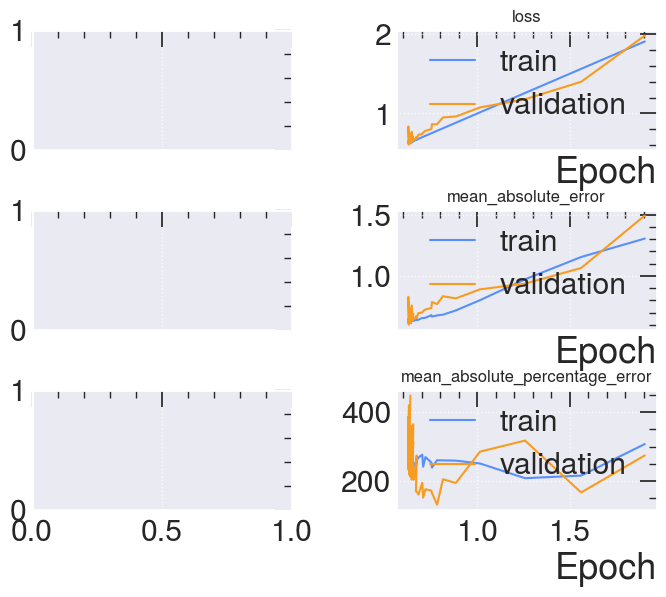

In [50]:
# history = None
# if train:
#     history = model.fit(fit_inputs,
#                         y_train,
#                         epochs=nepochs,
#                         batch_size=3000,
#                         validation_split=0.2,
#                         #sample_weight=wt,
#                         verbose=1,
#                         use_multiprocessing=True,
#                         callbacks=callback_list)
#     PlotHistory(loss_history, path=tagdir)
# else:
#     checkpoint_path = hereismodel
#     checkpoint_dir = os.path.dirname(hereismodel)
#     model = getmodel(tag=tag_)
#     model.load_weights(checkpoint_path)
#     print(f"Loaded model from checkpoint path: {checkpoint_path}")

history = None


print(len(model.inputs))

nepochs = 50
# print(fit_inputs)
if train:
    history = model.fit(
        fit_inputs,
        y_train,
        epochs=nepochs,
        batch_size=3000,
        validation_split=0.2,
        verbose=1,
        # callbacks=callback_list
    )
    PlotHistory(history, path=tagdir)
else:
    checkpoint_path = hereismodel
    checkpoint_dir = os.path.dirname(hereismodel)
    model = getmodel(tag=tag_)
    model.load_weights(checkpoint_path)
    print(f"Loaded model from checkpoint path: {checkpoint_path}")



2025-02-27:14:08:57,519 INFO     [247130123.py:33] Plot saved: /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25/Loss_Acc_LR_GluGluHToTauTauFlat_ForTrain_Raw_11_simple_IC_20240627_163559_nPart_10_executed_on_20250227_135723.png


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
variables: ['loss', 'mean_absolute_error', 'mean_absolute_percentage_error']
var =  loss
var =  mean_absolute_error
var =  mean_absolute_percentage_error
Curves saved as /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25/Loss_Acc_LR_GluGluHToTauTauFlat_ForTrain_Raw_11_simple_IC_20240627_163559_nPart_10_executed_on_20250227_135723.png


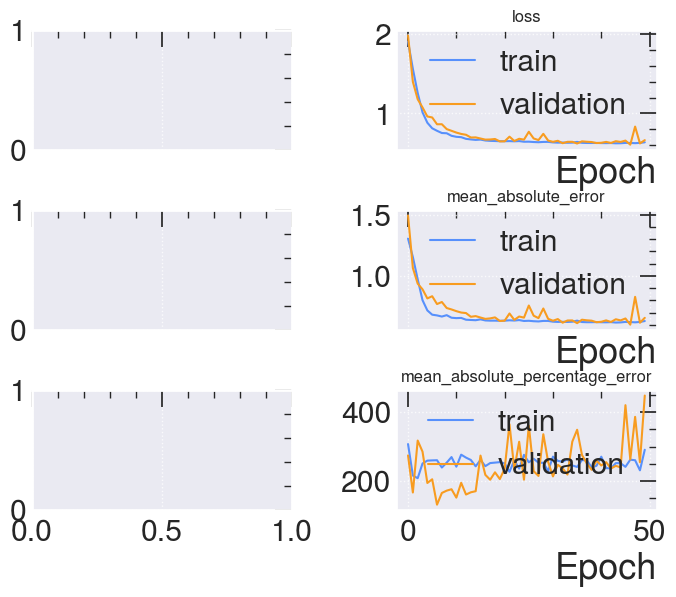

In [70]:
print(history.epoch)

PlotHistory(history, path=tagdir)


In [51]:
"""
loadmodel = None
if train: 
    PlotHistory(loss_history, path=tagdir)
else:
    checkpoint_path = f"{tagdir}/training_20231102-154447/cp.ckpt"
    checkpoint_dir = os.path.dirname(checkpoint_path)
    loadmodel = getmodel(tag=tag_)
    loadmodel.load_weights(checkpoint_path)
    print(f"Loaded model from checkpoint path: {checkpoint_path}")
"""

'\nloadmodel = None\nif train: \n    PlotHistory(loss_history, path=tagdir)\nelse:\n    checkpoint_path = f"{tagdir}/training_20231102-154447/cp.ckpt"\n    checkpoint_dir = os.path.dirname(checkpoint_path)\n    loadmodel = getmodel(tag=tag_)\n    loadmodel.load_weights(checkpoint_path)\n    print(f"Loaded model from checkpoint path: {checkpoint_path}")\n'

In [73]:
#if not train:
#    model = loadmodel
target_reg_val_train   = model.predict(fit_inputs)
target_val_train = y_train
target_reg_val_test    = model.predict(fit_tests)
target_val_test  = y_test

5423/5423 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step
1356/1356 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


In [74]:
if scaler_y is not None:
    target_reg_val_train = scaler_y.inverse_transform(target_reg_val_train)
    target_val_train     = scaler_y.inverse_transform(target_val_train)
    target_reg_val_test  = scaler_y.inverse_transform(target_reg_val_test)
    target_val_test      = scaler_y.inverse_transform(target_val_test)

In [79]:
target_regr = None
target_true = None
if evaluate:
    target_regr = np.concatenate((target_reg_val_train, target_reg_val_test), axis=0)
    target_true = np.concatenate((target_val_train, target_val_test), axis=0)



## Extract LBN layer from the model

In [ ]:
##layer = model.get_layer('LBN')
##print(layer)


In [ ]:
def plot1D(arrs, keys, bins, span, logy):
    fig, ax = plt.subplots(figsize=(6, 4))
    for i in range(len(arrs)):
        arr = arrs[i]
        key = keys[i]
        ax.hist(arr, bins=bins, range=span, alpha=0.8, label = key, log=logy)
        ax.set_xlabel(key)
    plt.tight_layout()
    plt.show()

In [ ]:
layer_name = 'LBN'
intermediate_layer_model = tf.keras.Model(inputs=model.input,
                                          outputs=model.get_layer(layer_name).output)
intermediate_output = intermediate_layer_model(fit_inputs)

In [ ]:
intermediate_output
#for i in range(intermediate_output.shape[-1]):
#    arr = intermediate_output[:,i:i+1].numpy()
#    plot1D([arr], [""], 50, None, True)

In [ ]:


intermediate_output[:,0:1]

/pbs/home/o/oponcet/private/TauRegression/venv/lib64/python3.9/site-packages/numpy/lib/histograms.py:883: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
2025-02-27:14:12:45,827 INFO     [3258850240.py:19] Plot saved: /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25/output_test_GluGluHToTauTauFlat_ForTrain_Raw_11_simple_IC_20240627_163559_nPart_10_executed_on_20250227_135723.png


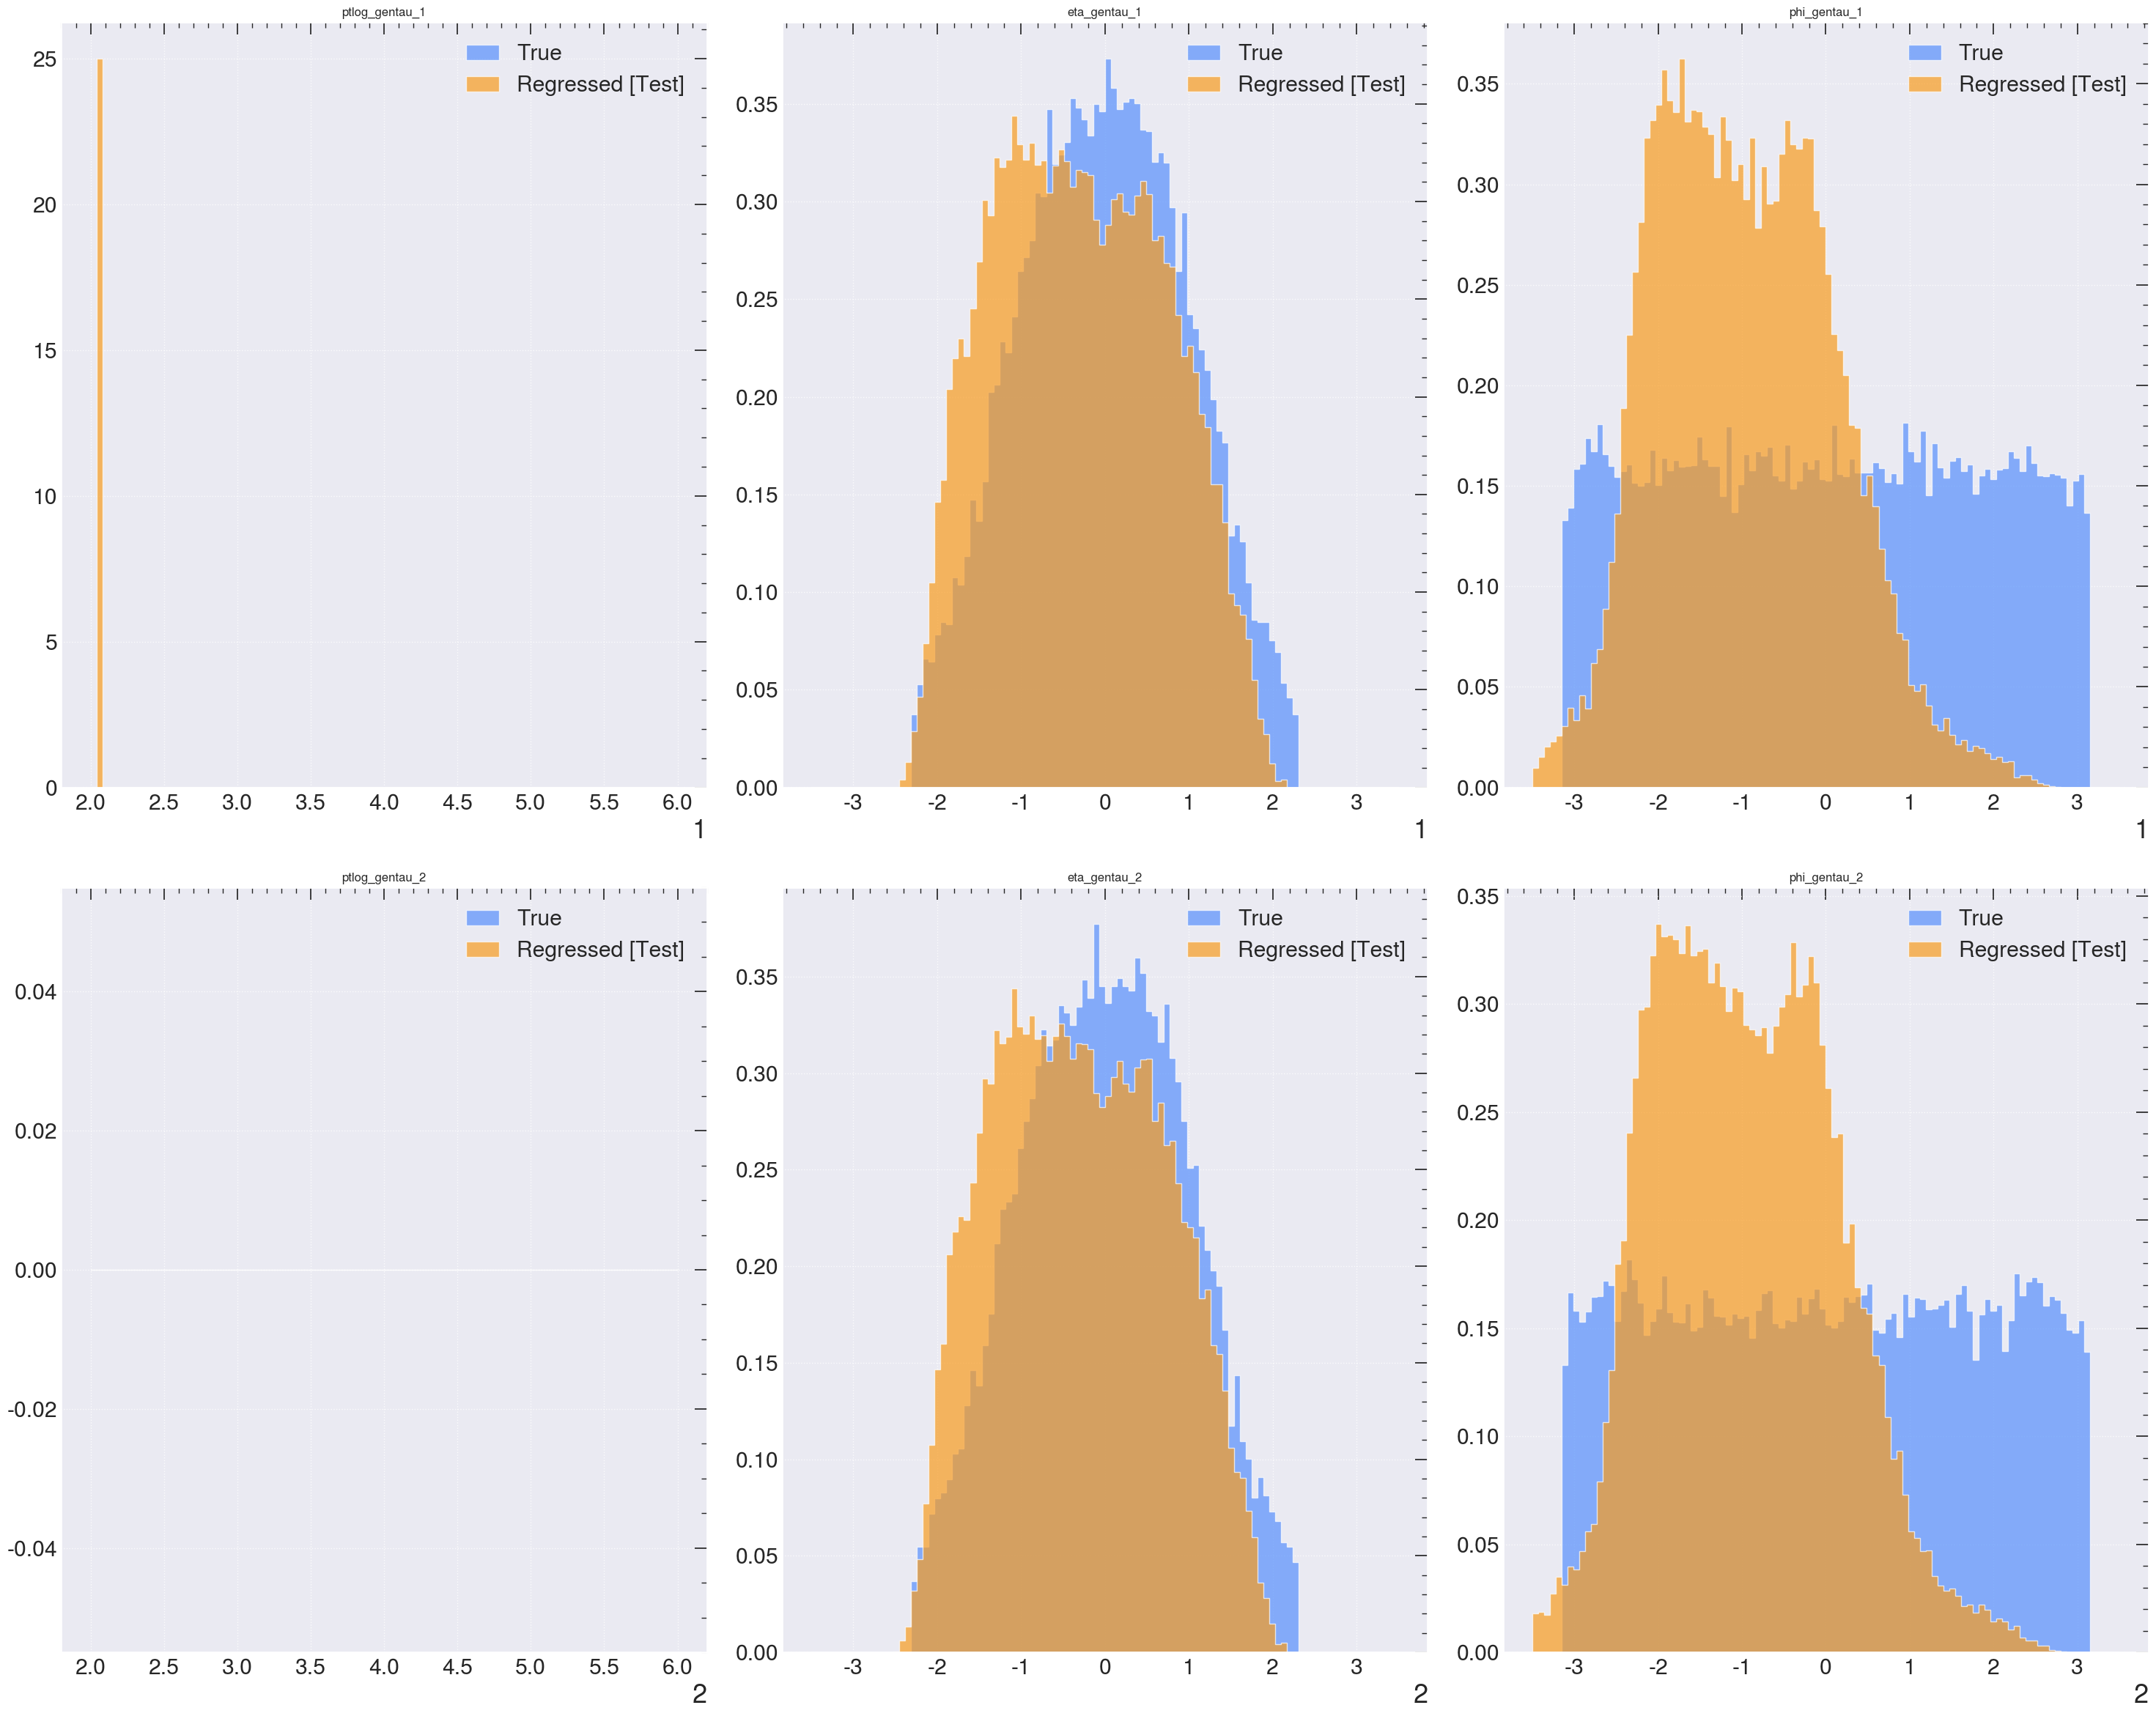

In [80]:
plt.figure(figsize=(30,24))
for idx, key in enumerate(targets):
    idx=idx+1
    ax = plt.subplot(2,3,idx)
    arr_true = target_val_test[:,(idx-1):idx].reshape(-1)
    arr_pred = target_reg_val_test[:,(idx-1):idx].reshape(-1)

    #print(arr)
    minmax = [2,6] if idx == 1 or idx == 4 else [-3.5,3.5]
    ax.hist(arr_true, 100, histtype="stepfilled", alpha=0.7, label='True', log=False, density=True,
            range=minmax)
    ax.hist(arr_pred, 100, histtype="stepfilled", alpha=0.7, label='Regressed [Test]', log=False, density=True,
            range=minmax)
    ax.set_title(f"{key}")
    ax.set_xlabel(f"""{key.split('_')[-1]}""")
    ax.legend()

pngname = os.path.join(tagdir,f'output_test_{df_tag_}.png')
logger.info(f"Plot saved: {pngname}")
plt.tight_layout()
plt.savefig(pngname, dpi=300)

In [ ]:
"""
plt.figure(figsize=(20,16))
for idx, key in enumerate(targets):
    idx=idx+1
    ax = plt.subplot(4,3,idx)
    arr_true = target_val_test[:,(idx-1):idx].reshape(-1)
    arr_pred = target_reg_val_test[:,(idx-1):idx].reshape(-1)

    #print(arr)
    minmax = [0,50] #if idx%4 == 0 else [0,6.5]
    ax.hist(np.abs(arr_true), 50, range=minmax, histtype="stepfilled", alpha=0.7, label='True')
    ax.hist(np.abs(arr_pred), 50, range=minmax, histtype="stepfilled", alpha=0.7, label='Regressed [Test]')
    ax.set_title(f"{key}")
    ax.set_xlabel(f"{key.split('_')[-1]}")
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(tagdir,'output_test_abs.png'), dpi=300)
"""

2025-02-27:14:13:59,382 INFO     [846820295.py:20] Plot saved: /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25/output_train_GluGluHToTauTauFlat_ForTrain_Raw_11_simple_IC_20240627_163559_nPart_10_executed_on_20250227_135723.png


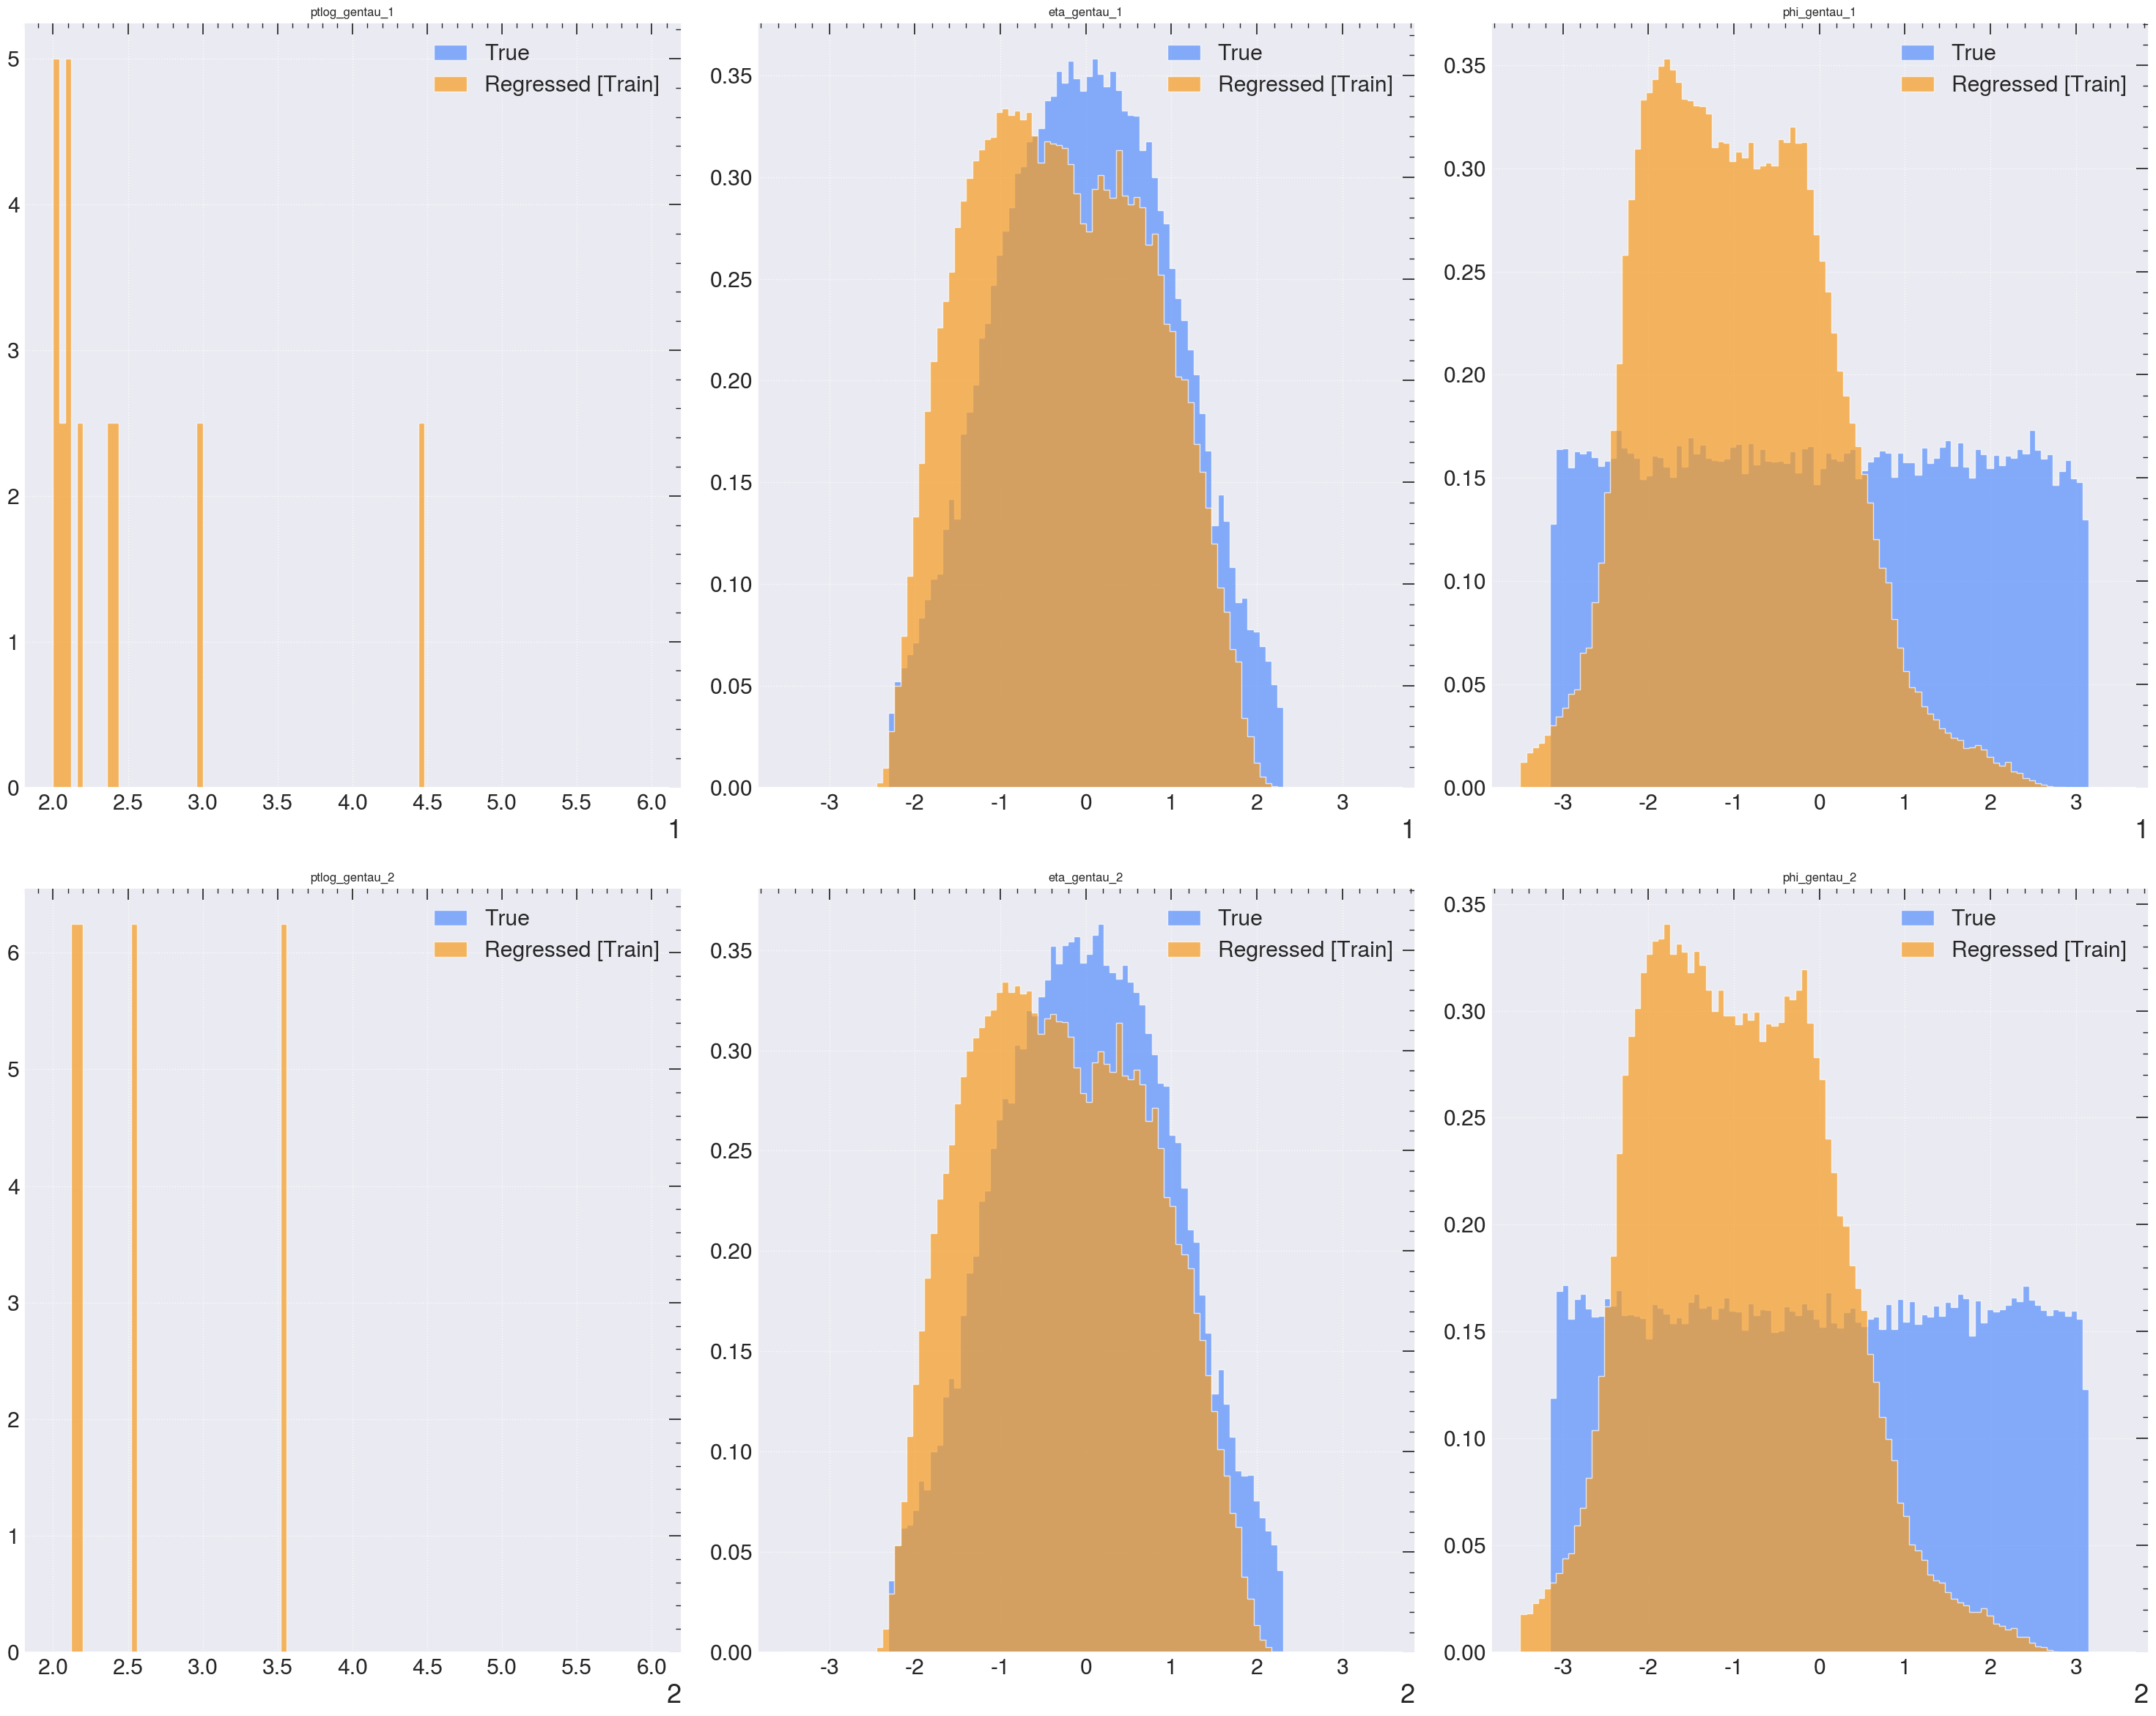

In [81]:
plt.figure(figsize=(30,24))
for idx, key in enumerate(targets):
    idx=idx+1
    ax = plt.subplot(2,3,idx)
    arr_true = target_val_train[:,(idx-1):idx].reshape(-1)
    arr_pred = target_reg_val_train[:,(idx-1):idx].reshape(-1)

    #print(arr)
    #minmax = [-50,50] if np.min(arr_true) < 0 else [0,1]
    minmax = [2,6] if idx == 1 or idx == 4 else [-3.5,3.5]
    ax.hist(arr_true, 100, histtype="stepfilled", alpha=0.7, label='True', 
            log=False, density=True, range=minmax)
    ax.hist(arr_pred, 100, histtype="stepfilled", alpha=0.7, label='Regressed [Train]', 
            log=False, density=True, range=minmax)
    ax.set_title(f"{key}")
    ax.set_xlabel(f'''{key.split('_')[-1]}''')
    ax.legend()

pngname = os.path.join(tagdir,f'output_train_{df_tag_}.png')
logger.info(f"Plot saved: {pngname}")
plt.tight_layout()
plt.savefig(pngname, dpi=300)

In [ ]:
"""
plt.figure(figsize=(20,16))
for idx, key in enumerate(targets):
    idx=idx+1
    ax = plt.subplot(2,3,idx)
    arr_true = target_val_train[:,(idx-1):idx].reshape(-1)
    arr_pred = target_reg_val_train[:,(idx-1):idx].reshape(-1)

    #print(arr)
    minmax = [0,50] #if idx%4 == 0 else [0,50]
    ax.hist(np.abs(arr_true), 50, range=minmax, histtype="stepfilled", alpha=0.7, label='True')
    ax.hist(np.abs(arr_pred), 50, range=minmax, histtype="stepfilled", alpha=0.7, label='Regressed [Train]')
    ax.set_title(f"{key}")
    ax.set_xlabel(f"{key.split('_')[-1]}")
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(tagdir,'output_train_abs.png'), dpi=300)
"""

In [82]:
df_test["pt_gentau_1"].to_numpy()
gentau1p4 = vector.array({"pt" : df_test["pt_gentau_1"].to_numpy(),
                          "eta": df_test["eta_gentau_1"].to_numpy(),
                          "phi": df_test["phi_gentau_1"].to_numpy(),
                          "mass": 1.777*np.ones(df_test.shape[0])})
gentau2p4 = vector.array({"pt" : df_test["pt_gentau_2"].to_numpy(),
                          "eta": df_test["eta_gentau_2"].to_numpy(),
                          "phi": df_test["phi_gentau_2"].to_numpy(),
                          "mass": 1.777*np.ones(df_test.shape[0])})
genhp4 = gentau1p4 + gentau2p4

In [83]:
genhp4.mass

array([8.08171922, 7.12868987, 5.59199408, ..., 9.69365594, 9.13089182,
       9.23385729])

In [84]:
regr_tau1_p4 = vector.array({"pt" : np.exp(target_regr[:,:1]).reshape(-1),
                             "eta": target_regr[:,1:2].reshape(-1),
                             "phi": target_regr[:,2:3].reshape(-1),
                             "mass": 1.777*np.ones_like(target_regr[:,:1].reshape(-1))})
regr_tau2_p4 = vector.array({"pt" : np.exp(target_regr[:,3:4]).reshape(-1),
                             "eta": target_regr[:,4:5].reshape(-1),
                             "phi": target_regr[:,5:6].reshape(-1),
                             "mass": 1.777*np.ones_like(target_regr[:,:1].reshape(-1))})

In [ ]:
"""
regr_tau1_p4 = vector.array({"px": target_regr[:,:1].reshape(-1),
                             "py": target_regr[:,1:2].reshape(-1),
                             "pz": target_regr[:,2:3].reshape(-1),
                             "M" : 1.777*np.ones_like(target_regr[:,:1].reshape(-1))})
regr_tau2_p4 = vector.array({"px": target_regr[:,3:4].reshape(-1),
                             "py": target_regr[:,4:5].reshape(-1),
                             "pz": target_regr[:,5:6].reshape(-1),
                             "M" : 1.777*np.ones_like(target_regr[:,:1].reshape(-1))})
"""

In [85]:
regr_tau1_p4.M, regr_tau2_p4.M

(array([1.777, 1.777, 1.777, ..., 1.777, 1.777, 1.777], dtype=float32),
 array([1.777, 1.777, 1.777, ..., 1.777, 1.777, 1.777], dtype=float32))

In [86]:
regr_h_p4 = regr_tau1_p4 + regr_tau2_p4
regr_h_p4.M

array([3.554621 , 3.5543506, 3.5580685, ..., 3.5588703, 3.569355 ,
       3.560195 ], dtype=float32)

2025-02-27:14:14:28,699 INFO     [186737635.py:11] Plot saved: /pbs/home/o/oponcet/private/TauRegression/BasicNN/DNN_Higgs_Flat_Feb25/mass_tau_tau_GluGluHToTauTauFlat_ForTrain_Raw_11_simple_IC_20240627_163559_nPart_10_executed_on_20250227_135723.png


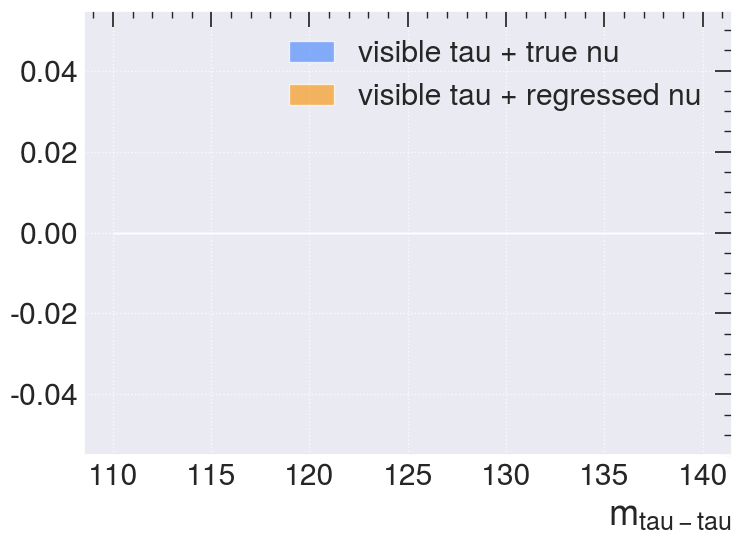

In [87]:
plt.figure(figsize=(8,6))

plt.hist(genhp4.mass, range=[110,140], bins=100, histtype="stepfilled", alpha=0.7, label="visible tau + true nu")
plt.hist(regr_h_p4.M, range=[110,140], bins=100, histtype="stepfilled", alpha=0.7, label="visible tau + regressed nu")
plt.xlabel("$m_{tau-tau}$")
plt.legend()


plt.tight_layout()
pngname = os.path.join(tagdir,f'mass_tau_tau_{df_tag_}.png')
logger.info(f"Plot saved: {pngname}")
plt.savefig(pngname, dpi=300)
plt.show()

In [88]:
pi1_p4 = getp4(df, vars=["pt_tau1pi_1","eta_tau1pi_1","phi_tau1pi_1","mass_tau1pi_1"], LVtype="ptetaphim")
pi2_p4 = getp4(df, vars=["pt_tau2pi_1","eta_tau2pi_1","phi_tau2pi_1","mass_tau2pi_1"], LVtype="ptetaphim")
pi01_p4 = getp4(df, vars=["pt_tau1pi0_1","eta_tau1pi0_1","phi_tau1pi0_1","mass_tau1pi0_1"], LVtype="ptetaphim")
pi02_p4 = getp4(df, vars=["pt_tau2pi0_1","eta_tau2pi0_1","phi_tau2pi0_1","mass_tau2pi0_1"], LVtype="ptetaphim")

In [89]:
import awkward as ak
from coffea.nanoevents.methods import vector
def getakp4(tau1_full_p4, pid):
    return ak.zip(
        {
            "pt": ak.Array(tau1_full_p4.pt[:,None]),
            "eta": ak.Array(tau1_full_p4.eta[:,None]),
            "phi": ak.Array(tau1_full_p4.phi[:,None]),
            "mass": ak.Array(tau1_full_p4.mass[:,None]),
            "pdgId": pid*ak.ones_like(ak.Array(tau1_full_p4.mass[:,None])),
        },
        with_name="PtEtaPhiMLorentzVector",
        behavior=vector.behavior
    )

ModuleNotFoundError: No module named 'awkward'

In [ ]:
tau1_full_p4 = getakp4(regr_tau1_p4, 15)
tau2_full_p4 = getakp4(regr_tau2_p4, 15)
pi1_p4 = getakp4(pi1_p4, 211)
pi2_p4 = getakp4(pi2_p4, 211)
pi01_p4 = getakp4(pi01_p4, 111)
pi02_p4 = getakp4(pi02_p4, 111)

In [ ]:
# Construct H mass from tau visible from the decay products pion and pi0
tau1p4_vis = pi1_p4 + pi01_p4
tau2p4_vis = pi2_p4 + pi02_p4
Hp4_vis = tau1p4_vis + tau2p4_vis



In [ ]:
plt.figure(figsize=(8,6))

plt.hist(Hp4_vis.mass, range=[20,140], bins=100, histtype="stepfilled", alpha=0.7)
#plt.hist(regr_h_p4.M, range=[110,140], bins=100, histtype="stepfilled", alpha=0.7, label="visible tau + regressed nu")
plt.xlabel("$m_{\tau-\tau}$ (visible)")
#plt.legend()

plt.tight_layout()
pngname = os.path.join(tagdir,f'mass_tau_tau_vis_{df_tag_}.png')
logger.info(f"Plot saved: {pngname}")
plt.savefig(pngname, dpi=300)
plt.show()

In [ ]:
plt.figure(figsize=(8,6))

plt.hist(pi01_p4.mass, range=[0,0.2], bins=100, histtype="stepfilled", alpha=0.7, label="$m_{\pi 0}^1$")
plt.hist(pi02_p4.mass, range=[0,0.2], bins=100, histtype="stepfilled", alpha=0.7, label="$m_{\pi 0}^2$")
#plt.hist(regr_h_p4.M, range=[110,140], bins=100, histtype="stepfilled", alpha=0.7, label="visible tau + regressed nu")
plt.xlabel("$m_{\pi 0}$ (GeV)")
plt.legend()

plt.tight_layout()
pngname = os.path.join(tagdir,f'mass_pi0s_{df_tag_}.png')
logger.info(f"Plot saved: {pngname}")
plt.savefig(pngname, dpi=300)
plt.show()

In [ ]:
tau1_full_p4.pt, pi02_p4.pt

In [ ]:
tau1_decay = ak.concatenate([pi1_p4,pi01_p4], axis=1)
tau2_decay = ak.concatenate([pi2_p4,pi02_p4], axis=1)
tau1_decay.pt, tau2_decay.pt

In [ ]:
#ak.to_list(tau2_full_p4.pt)

In [ ]:
#ak.to_list(tau2_decay.pt)

In [ ]:
from PhiCPComp import PhiCPComp
phicp_obj = PhiCPComp(cat="rhorho",
                      taum=tau1_full_p4,
                      taup=tau2_full_p4,
                      taum_decay=tau1_decay,
                      taup_decay=tau2_decay)
phi_cp, hk_dict = phicp_obj.comp_phiCP()
phi_cp = ak.firsts(phi_cp, axis=1)
phi_cp

In [ ]:
phicp_det = phi_cp
phicp_gen = ak.Array(df["phicp"])
phicp_det_true_tau = ak.Array(df["phi_cp_det"])
phicp_det, phicp_gen, phicp_det_true_tau

In [ ]:
#plt.figure(12,8)
plt.hist(ak.to_numpy(phicp_det), bins=25, label="Full Det", density=True, alpha=0.9, lw=2, histtype="step")
plt.hist(ak.to_numpy(phicp_det_true_tau), bins=25, label="Gen tau + det decays", density=True, alpha=0.9, lw=2, histtype="step")
plt.hist(ak.to_numpy(phicp_gen), bins=25, label="Full Gen", density=True, alpha=0.9, lw=2, histtype="step")

plt.legend()
plt.tight_layout()
pngname = os.path.join(tagdir,f'PhiCP_{df_tag_}.png')
logger.info(f"Plot saved: {pngname}")
plt.savefig(pngname, dpi=300)
plt.show()

In [ ]:
hk_dict

In [ ]:
conv = lambda x : ak.fill_none(ak.flatten(x),0).to_numpy()

In [ ]:
h1_det = hk_dict["h1_unit"]

h1x_det = conv(h1_det.x)
h1x_gen = df["h1x"].to_numpy()
h1y_det = conv(h1_det.y)
h1y_gen = df["h1y"].to_numpy()
h1z_det = conv(h1_det.z)
h1z_gen = df["h1z"].to_numpy()

h2_det = hk_dict["h2_unit"]

h2x_det = conv(h2_det.x)
h2x_gen = df["h2x"].to_numpy()
h2y_det = conv(h2_det.y)
h2y_gen = df["h2y"].to_numpy()
h2z_det = conv(h2_det.z)
h2z_gen = df["h2z"].to_numpy()

k1_det = hk_dict["k1_unit"]

k1x_det = conv(k1_det.x)
k1x_gen = df["k1x"].to_numpy()
k1y_det = conv(k1_det.y)
k1y_gen = df["k1y"].to_numpy()
k1z_det = conv(k1_det.z)
k1z_gen = df["k1z"].to_numpy()

k2_det = hk_dict["k2_unit"]

k2x_det = conv(k2_det.x)
k2x_gen = df["k2x"].to_numpy()
k2y_det = conv(k2_det.y)
k2y_gen = df["k2y"].to_numpy()
k2z_det = conv(k2_det.z)
k2z_gen = df["k2z"].to_numpy()

In [ ]:
def fastplot(arrs1, arrs2, tag='h'):
    fig, ax = plt.subplots(2,3,figsize=(12.5,8))

    ax[0,0].hist(arrs1[0], 100, histtype="stepfilled", alpha=0.7, label='Gen', log=False, density=True)
    ax[0,0].hist(arrs2[0], 100, histtype="stepfilled", alpha=0.7, label='Reco', log=False, density=True)
    ax[0,0].set_title(f"{tag}1x")
    ax[0,0].legend()
    
    ax[0,1].hist(arrs1[1], 100, histtype="stepfilled", alpha=0.7, label='Gen', log=False, density=True)
    ax[0,1].hist(arrs2[1], 100, histtype="stepfilled", alpha=0.7, label='Reco', log=False, density=True)
    ax[0,1].set_title(f"{tag}1y")
    ax[0,1].legend()

    ax[0,2].hist(arrs1[2], 100, histtype="stepfilled", alpha=0.7, label='Gen', log=False, density=True)
    ax[0,2].hist(arrs2[2], 100, histtype="stepfilled", alpha=0.7, label='Reco', log=False, density=True)
    ax[0,2].set_title(f"{tag}1z")
    ax[0,2].legend()
    
    ax[1,0].hist(arrs1[3], 100, histtype="stepfilled", alpha=0.7, label='Gen', log=False, density=True)
    ax[1,0].hist(arrs2[3], 100, histtype="stepfilled", alpha=0.7, label='Reco', log=False, density=True)
    ax[1,0].set_title(f"{tag}2x")
    ax[1,0].legend()
    
    ax[1,1].hist(arrs1[4], 100, histtype="stepfilled", alpha=0.7, label='Gen', log=False, density=True)
    ax[1,1].hist(arrs2[4], 100, histtype="stepfilled", alpha=0.7, label='Reco', log=False, density=True)
    ax[1,1].set_title(f"{tag}2y")
    ax[1,1].legend()

    ax[1,2].hist(arrs1[5], 100, histtype="stepfilled", alpha=0.7, label='Gen', log=False, density=True)
    ax[1,2].hist(arrs2[5], 100, histtype="stepfilled", alpha=0.7, label='Reco', log=False, density=True)
    ax[1,2].set_title(f"{tag}2z")
    ax[1,2].legend()

    plt.tight_layout()
    pngname = os.path.join(tagdir,f'{tag}_{df_tag_}.png')
    logger.info(f"Plot saved: {pngname}")
    plt.savefig(pngname, dpi=300)

In [ ]:
fastplot([h1x_gen,h1y_gen,h1z_gen,h2x_gen,h2y_gen,h2z_gen],
         [h1x_det,h1y_det,h1z_det,h2x_det,h2y_det,h2z_det], tag='h')

In [ ]:
fastplot([k1x_gen,k1y_gen,k1z_gen,k2x_gen,k2y_gen,k2z_gen],
         [k1x_det,k1y_det,k1z_det,k2x_det,k2y_det,k2z_det], tag='k')